**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

*Edición 2025*

Mentoría 17 - Inventarios Forestales Nacionales, calculo de biomasa y evaluación del estado de los bosques nativos.

**GRUPO 1**

**Integrantes:**

- *Ana Luz Alabi Nassr*
- *Guillermo Poggioni*

**Mentor:**

- *Anibal Cuchietti*


----

### Práctico 3 de aprendizaje supervisado o no supervisado
**Consigna:**
> Estimar la altura de los arboles fuera de rango o con datos faltantes usando distintos modelos de regresion para encontrar el mas adecuado  segun la naturaleza de los datos seleccionados. 

----

## Introducción:
#### Para cumplir con la consigna del entregable seguiremos estos pasos:
> ----
>1. Variable objetivo: ALTURA_TOTAL_M.
>2. Copia de trabajo: crearemos una copia del dataset para explorarlo, curarlo y usarlo en los modelos.
>3. Tratamiento de valores extremos (outliers): definiremos outliers en la variable objetivo usando el umbral del cuantil 0.99. Los valores por encima de ese límite se convertirán en NaN. El subconjunto con NaN en la variable objetivo constituirá el conjunto a predecir.
>4. Partición de datos: el resto de los registros (con objetivo no nulo) se dividirá en Entrenamiento (70 %) y Validación (30 %).
>5. Modelado (tarea de regresión): intentaremos predecir ALTURA_TOTAL_M con:
>    - Random Forest Regressor.
>    - XGBoost Regressor.
>    - XGBRFR Regressor.
>6. Evaluación y explicabilidad: compararemos los modelos y seleccionaremos el mejor según métricas de regresión (p. ej., MAE, RMSE, R²).
>7. Integración de resultados: generaremos ALTURA_TOTAL_EST_FINAL en el dataset original, combinando:
>    - valores verdaderos de Entrenamiento,
>    - valores verdaderos de Validación,
>    - predicciones del Mejor Modelo para los registros con objetivo ausente.
> ----

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
import seaborn as sb
import missingno as msno
import shap

from sklearn.model_selection        import train_test_split, GridSearchCV, KFold, RandomizedSearchCV
from xgboost                        import XGBRegressor, XGBRFRegressor
from sklearn.ensemble               import RandomForestRegressor
from sklearn.metrics                import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score
from copy                           import deepcopy


## Lectura del dataset

In [4]:
url2 = 'https://raw.githubusercontent.com/poggiogu/DiploDatos2025_Mentoria_17/refs/heads/master/Data/data_individuos_pais_2021.csv'
df_individuos = pd.read_csv(url2, low_memory=False)
#df_individuos.head(3)
df_individuos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101229 entries, 0 to 101228
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   UM_ID_UM                    101229 non-null  int64  
 1   NO_INDIV                    101229 non-null  int64  
 2   PARCELA_CONCENTRICA         101229 non-null  object 
 3   ESPECIE_CORREGIDA           101229 non-null  object 
 4   REGION_OFC                  101229 non-null  object 
 5   SUBREG                      96093 non-null   object 
 6   ESTADO_INDIV                101229 non-null  object 
 7   ALTURA_TOTAL_M              101226 non-null  float64
 8   PROVINCIA                   101229 non-null  int64  
 9   COORDENADAS_GPS_LATITUDE2   101229 non-null  float64
 10  COORDENADAS_GPS_LONGITUDE2  101229 non-null  float64
 11  DAP_FINAL_M                 101229 non-null  float64
 12  ALTURA_TOTAL_EST            101229 non-null  float64
 13  VOL_M3        

In [5]:
# creamos un DF copia para poder alterar y realizar comparaciones en bloques de código posteriores:
df_individuos_c = df_individuos.copy()

#### Observamos y eliminamos variables con baja cantidad de valores no nulos o con información redundante

<Axes: >

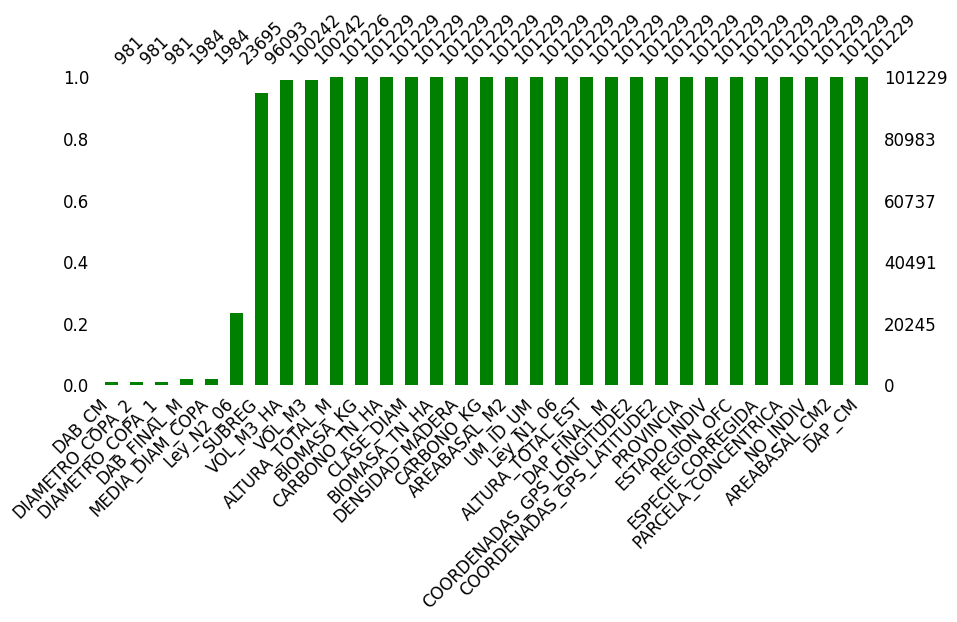

In [6]:
msno.bar(df_individuos_c, figsize=(10, 4), sort="ascending",fontsize=12, color='green')

In [7]:
# Dropeamos las columnas que no vamos a usar
df_filtrado_G = df_individuos_c.drop(columns=[
    'DIAMETRO_COPA_2',
    'DIAMETRO_COPA_1',
    'DAB_CM',
    'DAB_FINAL_M',
    'MEDIA_DIAM_COPA',
    'CARBONO_KG',
    'BIOMASA_KG',
    'AREABASAL_M2',
    'VOL_M3',
    'VOL_M3_HA',
    'DAP_CM',
    'Ley_N2_06',
    'SUBREG',
    'ALTURA_TOTAL_EST',
    'CARBONO_TN_HA',
    'CLASE_DIAM',
    'COORDENADAS_GPS_LATITUDE2',
    'COORDENADAS_GPS_LONGITUDE2'
    ])

print(f'Shape Antes: {df_individuos_c.shape}')
print(f'Shape Después: {df_filtrado_G.shape}')

Shape Antes: (101229, 31)
Shape Después: (101229, 13)


<Axes: >

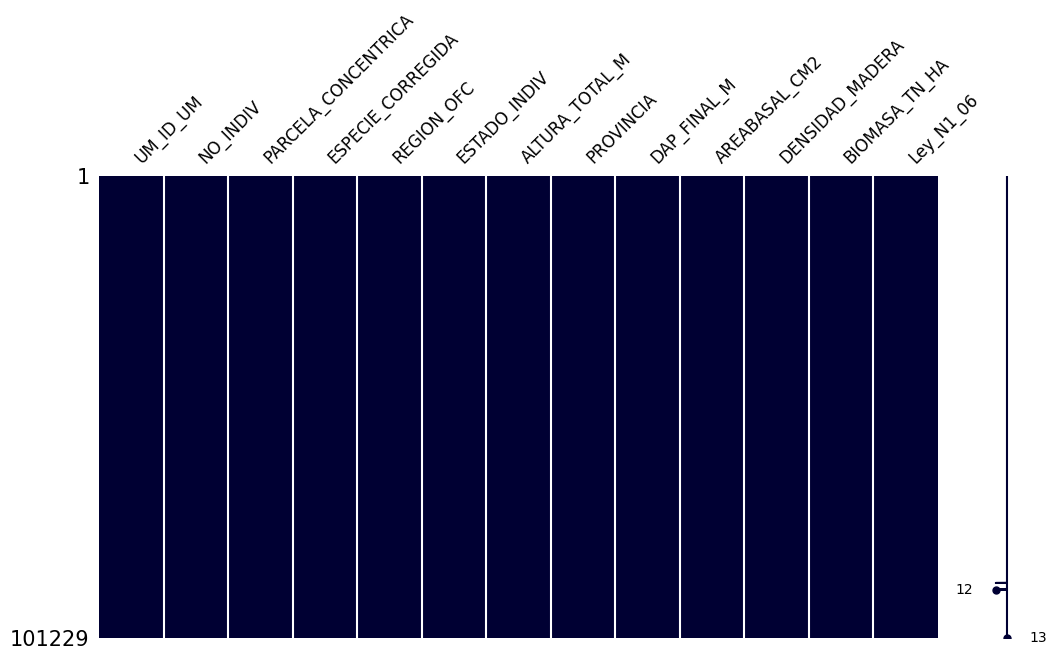

In [8]:
msno.matrix(df_filtrado_G,figsize=(12, 6), fontsize=12, color=[0,0,0.2])

In [9]:
len(df_filtrado_G[(df_filtrado_G['ESPECIE_CORREGIDA'] == 'UNLISTED')])

530

### Boxplot de la variable de "ALTURA" de los individuos en todo el dataset

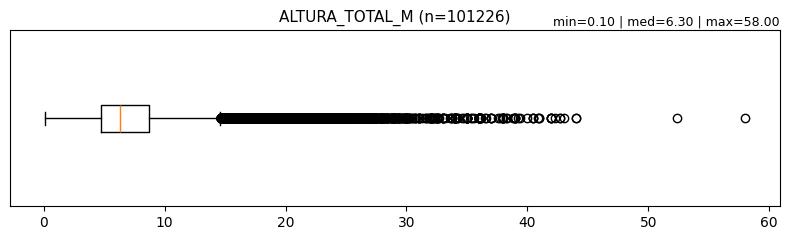

In [10]:
cols = ['ALTURA_TOTAL_M']
fig, axes = plt.subplots(len(cols), 1, figsize=(8, 2.5*len(cols)))
axes = np.atleast_1d(axes)

for ax, col in zip(axes, cols):
    s = df_filtrado_G[col].dropna()
    ax.boxplot(s,vert=False)
    ax.set_title(f"{col} (n={len(s)})", fontsize=11)
    ax.set_yticks([])

    
    mn, md, mx = float(s.min()), float(s.median()), float(s.max())
    ax.text(1.0, 1.05, f"min={mn:.2f} | med={md:.2f} | max={mx:.2f}",
            ha="right", va="center", transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.show()

### Analizamos los outliers de 'ALTURA_TOTAL_M' por región ya que entendemos que las distribuciones de ALTURA difieren ampliamente según cada clase de 'REGION_OFC' 

In [11]:
df = df_filtrado_G
TARGET = "ALTURA_TOTAL_M"
REGION = "REGION_OFC"

# definimos el cuantil para el calculo del umbral
Q = 0.99

# Umbral p99 por región
df["_p99_region"] = df.groupby(REGION)[TARGET].transform(lambda s: s.quantile(Q))

# Flag de outlier
df["_es_outlier_p99_reg"] = df[TARGET] > df["_p99_region"]

resumen = (
    df.groupby(REGION)
      .agg(n=(TARGET,"size"),
           p99=(TARGET, lambda s: s.quantile(Q)),
           outliers=("_es_outlier_p99_reg","sum"))
      .assign(outlier_rate=lambda d: d["outliers"]/d["n"])
      .sort_values("outlier_rate", ascending=False)
)
resumen.head(10)

,n,p99,outliers,outlier_rate
REGION_OFC,,,,
BAP,6908,32.979,70,0.010133
MON,1984,7.817,20,0.010081
STB,5136,27.500,50,0.009735
ESP,7008,13.300,68,0.009703
DEL,628,20.000,6,0.009554
SMI,3079,26.700,29,0.009419
PCH,76486,15.000,716,0.009361


In [12]:
resumen['outliers'].sum()

959

#### Boxplots con outliers por región

<Figure size 1000x500 with 0 Axes>

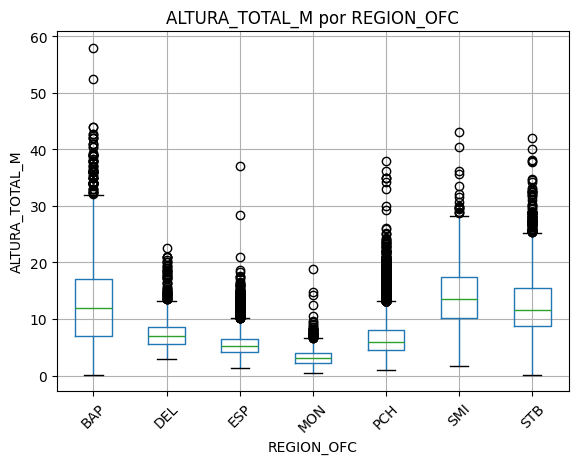

In [13]:
plt.figure(figsize=(10,5))
df.boxplot(column=TARGET, by=REGION, rot=45)
plt.title(f"{TARGET} por {REGION}")
plt.suptitle("")
plt.xlabel(REGION); plt.ylabel(TARGET)
plt.show()

In [14]:
df_sanit = df.copy()
df_sanit.loc[df_sanit["_es_outlier_p99_reg"], TARGET] = np.nan

In [15]:
print("Cantidad de registros con datos NaNs para ALTURA_TOTAL_M: ", len(df_sanit[df_sanit[TARGET].isna()]))

Cantidad de registros con datos NaNs para ALTURA_TOTAL_M:  962


Visualizamos nuevamente los boxplots de variables de ALTURA general de dataset

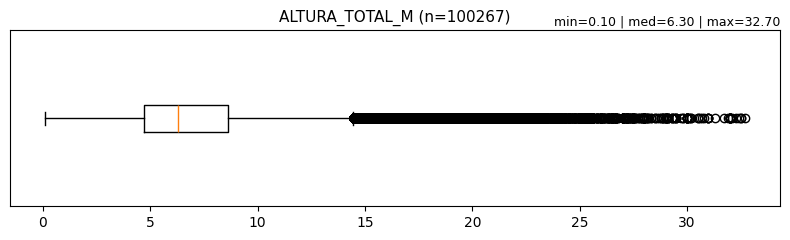

In [16]:
cols = ['ALTURA_TOTAL_M']
fig, axes = plt.subplots(len(cols), 1, figsize=(8, 2.5*len(cols)))
axes = np.atleast_1d(axes)

for ax, col in zip(axes, cols):
    s = df_sanit[col].dropna()
    ax.boxplot(s, vert=False)  # simple, horizontal
    ax.set_title(f"{col} (n={len(s)})", fontsize=11)
    ax.set_yticks([])

    mn, md, mx = float(s.min()), float(s.median()), float(s.max())
    ax.text(1.0, 1.05, f"min={mn:.2f} | med={md:.2f} | max={mx:.2f}",
            ha="right", va="center", transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.show()

Y tambien los boxplots por region nuevamente

<Figure size 1000x500 with 0 Axes>

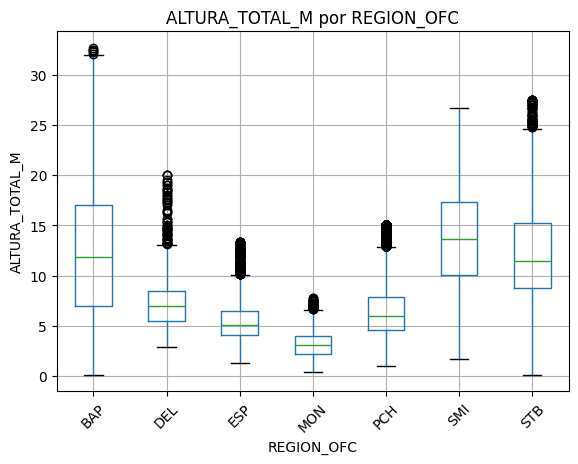

In [17]:
plt.figure(figsize=(10,5))
df_sanit.boxplot(column=TARGET, by=REGION, rot=45)
plt.title(f"{TARGET} por {REGION}")
plt.suptitle("")
plt.xlabel(REGION); plt.ylabel(TARGET)
plt.show()

#### Aplicamos OneHot encoding para aumentar la información disponible para nuestros modelos de regresión convirtiendo variables categóricas en numéricas.

 Determinamos las columnas a las que le aplicaremos One Hot Encoding. Utilizamos variables categóricas relevantes para nuestros futuros modelos y que a su vez no tengan un alto numero de clases, así podemos información util sin aumentar demasiado el número de dimensiones en el dataframe.

In [18]:
cols_onehot = ['REGION_OFC', 'Ley_N1_06', 'PARCELA_CONCENTRICA']
df_ind_onehot = pd.get_dummies(df_sanit, columns=cols_onehot, drop_first=False, dtype='int')
print(f'Cantidad de columnas antes del encoding: {df_sanit.shape[1]}')
print(f'Cantidad de columnas después del encoding: {df_ind_onehot.shape[1]}')


Cantidad de columnas antes del encoding: 15
Cantidad de columnas después del encoding: 24


Convertimos la variable ESTADO_IND a variable de tipo numérica y eliminamos posibles nans:

In [19]:
s = df_ind_onehot['ESTADO_INDIV'].astype(str).str.strip().replace({'-': None, '': None})
df_ind_onehot['ESTADO_INDIV'] = pd.to_numeric(s, errors='coerce').astype('Int64')
df_ind_onehot['ESTADO_INDIV'] = df_ind_onehot['ESTADO_INDIV'].fillna(0).astype(int) # llenamos los NaNs con 0
# Corroboramos que no tenga NaNs
df_ind_onehot['ESTADO_INDIV'].value_counts(dropna=False)

ESTADO_INDIV
1    70448
2    20366
3     7942
4     1713
0      760
Name: count, dtype: int64

In [20]:
columnas_num_oh= df_ind_onehot.select_dtypes(include=['number']).columns.tolist()
columnas_cat_oh = df_ind_onehot.select_dtypes(exclude=['number']).columns.tolist()
columnas_num_oh.append('REGION_OFC')
print("Columnas numéricas:", columnas_num_oh)
print("Columnas categóricas:", columnas_cat_oh)

Columnas numéricas: ['UM_ID_UM', 'NO_INDIV', 'ESTADO_INDIV', 'ALTURA_TOTAL_M', 'PROVINCIA', 'DAP_FINAL_M', 'AREABASAL_CM2', 'DENSIDAD_MADERA', 'BIOMASA_TN_HA', '_p99_region', 'REGION_OFC_BAP', 'REGION_OFC_DEL', 'REGION_OFC_ESP', 'REGION_OFC_MON', 'REGION_OFC_PCH', 'REGION_OFC_SMI', 'REGION_OFC_STB', 'Ley_N1_06_OT', 'Ley_N1_06_OTF', 'Ley_N1_06_TF', 'PARCELA_CONCENTRICA_A', 'PARCELA_CONCENTRICA_B', 'REGION_OFC']
Columnas categóricas: ['ESPECIE_CORREGIDA', '_es_outlier_p99_reg']


In [21]:
df_ind_onehot[columnas_cat_oh].nunique()

ESPECIE_CORREGIDA      458
_es_outlier_p99_reg      2
dtype: int64

#### Analizamos la matriz de correlación de las variables numéricas más importantes

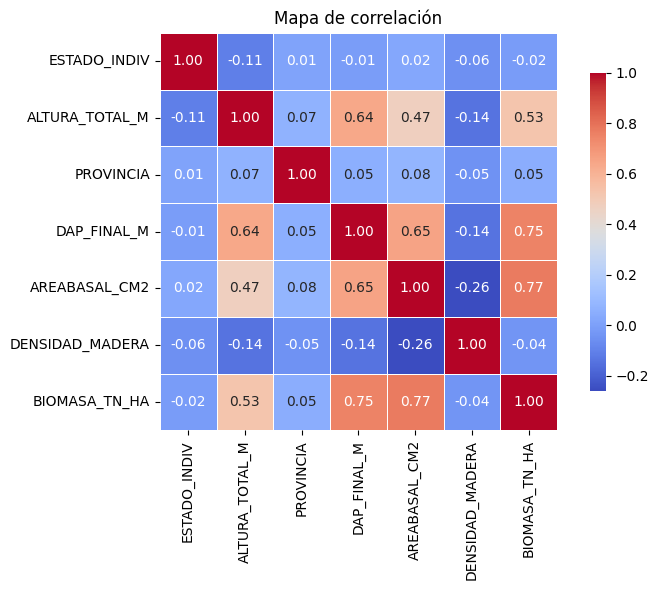

In [22]:
columnas_num_heatmap = ['ESTADO_INDIV', 'ALTURA_TOTAL_M', 'PROVINCIA','DAP_FINAL_M', 'AREABASAL_CM2', 'DENSIDAD_MADERA', 'BIOMASA_TN_HA']
df_corr = df_ind_onehot[columnas_num_heatmap].dropna()

# Calcular la matriz de correlación
corr_matrix = df_corr.corr(method='pearson')

plt.figure(figsize=(8,6))
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True,
            cbar_kws={"shrink": 0.8}, linewidths=0.5)
plt.title("Mapa de correlación")
plt.tight_layout()
plt.show()

----
----

### Generamos nuestros datasets de Entrenamiento y Test

In [23]:
# Agrego la columna 'REGION_OFC' nuevamente para usarla solo en la inspección
# de ouliers extremos en nuestro dataset de entrenamiento, para limpiar estos valores y suavizar
# columnas muy sesgadas. 
df_con_reg = df_ind_onehot.copy()
df_con_reg['REGION_OFC'] = df_individuos_c['REGION_OFC']

train_df = df_con_reg[columnas_num_oh][df_con_reg['ALTURA_TOTAL_M'].notna()].copy()
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100267 entries, 0 to 101228
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   UM_ID_UM               100267 non-null  int64  
 1   NO_INDIV               100267 non-null  int64  
 2   ESTADO_INDIV           100267 non-null  int32  
 3   ALTURA_TOTAL_M         100267 non-null  float64
 4   PROVINCIA              100267 non-null  int64  
 5   DAP_FINAL_M            100267 non-null  float64
 6   AREABASAL_CM2          100267 non-null  float64
 7   DENSIDAD_MADERA        100267 non-null  float64
 8   BIOMASA_TN_HA          100267 non-null  float64
 9   _p99_region            100267 non-null  float64
 10  REGION_OFC_BAP         100267 non-null  int32  
 11  REGION_OFC_DEL         100267 non-null  int32  
 12  REGION_OFC_ESP         100267 non-null  int32  
 13  REGION_OFC_MON         100267 non-null  int32  
 14  REGION_OFC_PCH         100267 non-null  i

Vemos rapidamente como quedaron nuestras distribuciones:

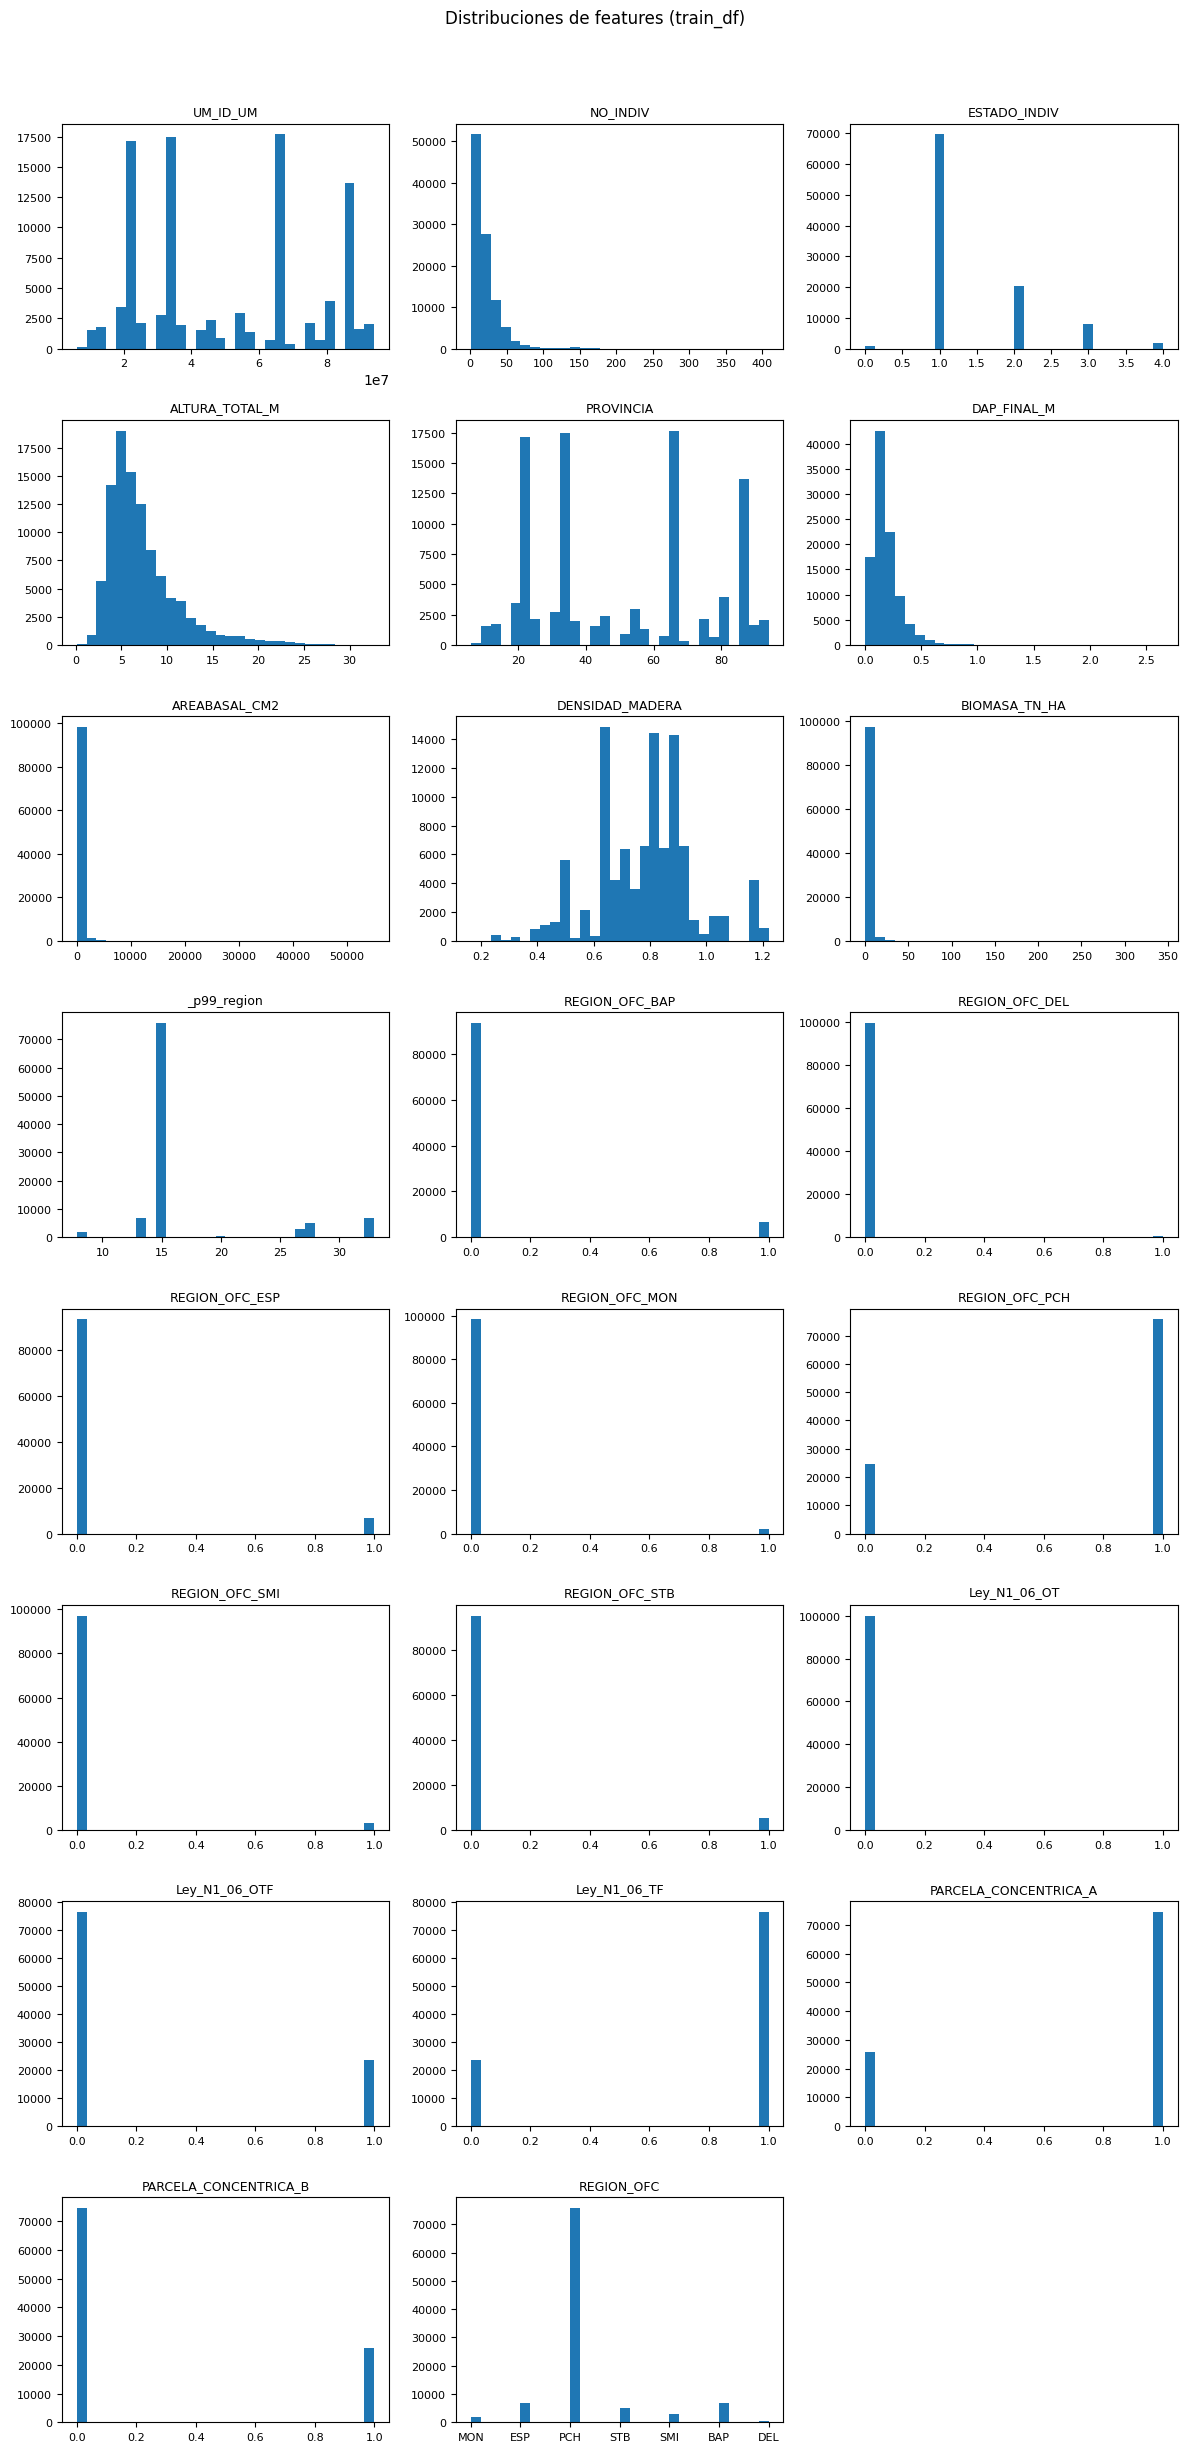

In [24]:
feature_names = [f"f_{i:02d}" for i in range(train_df.shape[1])]

n = train_df.shape[1]        # 22 variables 
ncols = 3                    # 3 columnas por fila
nrows = math.ceil(n / ncols) # 8 filas

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3), sharex=False, sharey=False)
axes = axes.ravel()

for i, col in enumerate(train_df.columns):
    axes[i].hist(train_df[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=8)

# con este loop oculto los axes vacios
for ax in axes[len(train_df.columns):]:
    ax.set_visible(False)  

fig.suptitle("Distribuciones de features (train_df)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

#### Hacemos el Control de outliers excesivos (usamos un umbral en p99) eliminando registros solo del df de entrenamiento

Hicimos una pequeña función reusable para el control de outliers en la que podemos dar el input del dataframe, las variables a ajustar, el umbral (q), y la variable por cual agruparlas (en este caso para agruparlas por región): 

In [25]:
# Variables que usamos para llamar la funcion en este caso en particular
GROUP_COL = "REGION_OFC"
VARS = ["NO_INDIV", "DAP_FINAL_M", "AREABASAL_CM2", "BIOMASA_TN_HA"]
Q = 0.99
MIN_N_PER_GROUP = 30 #esto es solo para los casos que alguno de los grupos tenga muy pocos registros

def drop_outliers_p99_by_region(df, group_col=GROUP_COL, vars_list=VARS,
                                q=Q, min_n_per_group=MIN_N_PER_GROUP):
    df = df.copy()

    # Checks basicos
    missing_cols = [c for c in [group_col, *vars_list] if c not in df.columns]
    if missing_cols:
        raise KeyError(f"Faltan columnas en df: {missing_cols}")

    # Umbrales p99 por grupo para cada variable con fallback global si hay pocos casos
    thresh_map_by_var = {}
    for v in vars_list:
        g = df.groupby(group_col)[v]
        stats = g.agg(n="count", p99=lambda s: s.quantile(q))
        p99_global = df[v].quantile(q)
        # si el grupo tiene pocos datos usamos p99 global como fallback 
        stats["p99_eff"] = np.where(stats["n"] >= min_n_per_group, stats["p99"], p99_global)
        thresh_map_by_var[v] = stats["p99_eff"]

    # Flags de outlier por variable y mascara combinada
    flags = {}
    mask_any = pd.Series(False, index=df.index)
    for v in vars_list:
        thr = df[group_col].map(thresh_map_by_var[v])  # umbral por fila segun su region
        flags[v] = df[v] > thr                          # True si outlier (> p99)
        mask_any = mask_any | flags[v]

    # Resumen por variable y región
    res_list = []
    for v in vars_list:
        thr_series = thresh_map_by_var[v]
        tmp = (
            df.assign(_flag=flags[v])
              .groupby(group_col)
              .agg(n=(v, "count"),
                   outliers=("_flag", "sum"))
              .assign(p99=lambda d: d.index.map(thr_series), 
                      outlier_rate=lambda d: d["outliers"]/d["n"])
              .reset_index()
              .assign(variable=v)
        )
        res_list.append(tmp)

    resumen = (pd.concat(res_list, ignore_index=True)
                 .sort_values(["variable", "outlier_rate", "n"],
                              ascending=[True, False, False]))

    # Separar removidos y conservar para ver resultados
    removed_df = df.loc[mask_any].copy()
    kept_df    = df.loc[~mask_any].copy()

    print(f"Filas totales: {len(df)}")
    print(f"Outliers detectados (alguna de {vars_list} > p99 por {group_col}): {mask_any.sum()}")
    print(f"Filas restantes tras remover: {len(kept_df)}")

    return kept_df, removed_df, resumen

In [26]:
train_df, outliers_df, resumen = drop_outliers_p99_by_region(train_df)

Filas totales: 100267
Outliers detectados (alguna de ['NO_INDIV', 'DAP_FINAL_M', 'AREABASAL_CM2', 'BIOMASA_TN_HA'] > p99 por REGION_OFC): 2342
Filas restantes tras remover: 97925


Inspeccionamos como quedaron las distribuciones despues de la limpieza de valores extremos por region: 

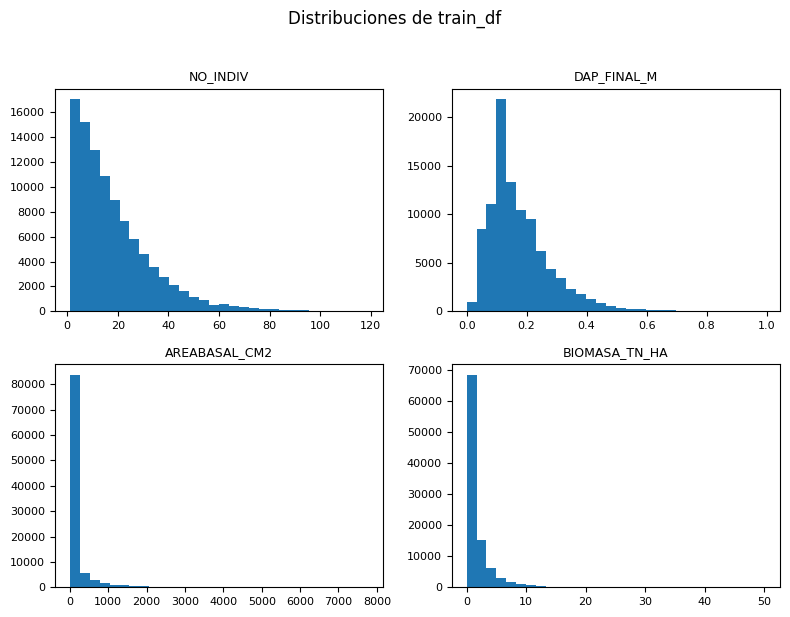

In [27]:
feature_names = ["NO_INDIV","DAP_FINAL_M","AREABASAL_CM2","BIOMASA_TN_HA"]

n = len(feature_names)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3), sharex=False, sharey=False)
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, feature_names):
    ax.hist(train_df[col].dropna(), bins=30)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=8)

for ax in axes[n:]:
    ax.set_visible(False) 

fig.suptitle("Distribuciones de train_df", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

>Las variables NO_INDIV, DAP_FINAL_M, AREABASAL_CM2 y BIOMASA_TN_HA muestran asimetría con cola derecha. Como los modelos que usaremos son basados en árboles (RF/XGB/XGBRF), no requieren estandarización: los árboles dividen por umbrales y las transformaciones monótonas no alteran el orden de los valores. Por ello, dejamos las distribuciones sin escalar y aplicamos solo imputación y control de outliers (cap p99 por región)

Ahora limpiamos train_DF y creamos nuestras variables de features "X" y target "y" 

In [28]:

# quitamos nuevamente la variable categórica de REGION_OFC porque no la usaremos en el resto del trabajo
train_df = train_df.drop(columns='REGION_OFC',axis=1)
# separamos el dataset en features "X" y target "y"
y = train_df.ALTURA_TOTAL_M
X = train_df.drop('ALTURA_TOTAL_M',axis=1)
print(y.head(3))
X.head(3)


0    4.2
1    4.8
2    4.4
Name: ALTURA_TOTAL_M, dtype: float64


,UM_ID_UM,NO_INDIV,ESTADO_INDIV,PROVINCIA,DAP_FINAL_M,AREABASAL_CM2,DENSIDAD_MADERA,BIOMASA_TN_HA,_p99_region,REGION_OFC_BAP,...,REGION_OFC_ESP,REGION_OFC_MON,REGION_OFC_PCH,REGION_OFC_SMI,REGION_OFC_STB,Ley_N1_06_OT,Ley_N1_06_OTF,Ley_N1_06_TF,PARCELA_CONCENTRICA_A,PARCELA_CONCENTRICA_B
0,6074195,1,2,6,0.118381,110.065699,0.792,0.270712,7.817,0,...,0,1,0,0,0,0,1,0,1,0
1,6074195,3,3,6,0.101607,81.084506,0.715,0.207121,7.817,0,...,0,1,0,0,0,0,1,0,1,0
2,6074195,8,4,6,0.082219,53.092916,0.715,0.125851,7.817,0,...,0,1,0,0,0,0,1,0,1,0


A partir de los datos en las variables `X` e `y` separamos en train y en test:

In [29]:
RANDOM_STATE = 42 #Mantenemos siempre el mismo random state para poder reproducir
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state = RANDOM_STATE)

Este dataframe de "Test" es el que tiene los registros con valores NaN para la variable TARGET, y en la cual vamos a estimarlos luego de entrenar y evaluar nuestros modelos.

In [30]:
columnas_num_oh= df_ind_onehot.select_dtypes(include=['number']).columns.tolist()
test_df = df_ind_onehot[columnas_num_oh][df_ind_onehot['ALTURA_TOTAL_M'].isna()].copy()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 962 entries, 171 to 101036
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   UM_ID_UM               962 non-null    int64  
 1   NO_INDIV               962 non-null    int64  
 2   ESTADO_INDIV           962 non-null    int32  
 3   ALTURA_TOTAL_M         0 non-null      float64
 4   PROVINCIA              962 non-null    int64  
 5   DAP_FINAL_M            962 non-null    float64
 6   AREABASAL_CM2          962 non-null    float64
 7   DENSIDAD_MADERA        962 non-null    float64
 8   BIOMASA_TN_HA          962 non-null    float64
 9   _p99_region            962 non-null    float64
 10  REGION_OFC_BAP         962 non-null    int32  
 11  REGION_OFC_DEL         962 non-null    int32  
 12  REGION_OFC_ESP         962 non-null    int32  
 13  REGION_OFC_MON         962 non-null    int32  
 14  REGION_OFC_PCH         962 non-null    int32  
 15  REGION

In [31]:
# eliminamos la columna objetivo del set test_df
# porque lo vamos a predecir al final del TP3
test_df = test_df.drop(columns=['ALTURA_TOTAL_M'])

----
----

## Planteo de los Modelos de regresión

- Vamos a implementar **Random Forest**, **XGBoost** y **XGRFBoost**.
- En cada caso usaremos Search para identificar la mejor combinación de hiperparámetros: 
    - RandomizedSearchCV para Random Forest  
    - GridSearchCV para XGBoost y XGRFBoost

----
### Random Forest

In [ ]:
# RandomizedSearchCV
rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=1,                 
    bootstrap=True,
    n_estimators=200,        
    max_samples=0.8          
)

param_dist_rf = {
    "max_depth": [None, 16, 20],
    "min_samples_split": [2, 5,],
    "min_samples_leaf": [1, 4],
    #"max_features": ["sqrt", "log2", 0.7, 1.0]
}

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE) # Lo bajé a n_splits = 3 para mejorar un poco el rendimiento en el local

rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,                         
    refit=True,
    verbose=1,
    random_state=RANDOM_STATE
)

rs.fit(X_train, y_train)

print("Mejores params:", rs.best_params_)
y_pred = rs.best_estimator_.predict(X_test)
print(
    f"[TEST] MAE={mean_absolute_error(y_test, y_pred):.4f}  "
    f"RMSE={mean_squared_error(y_test, y_pred):.4f}  "
    f"R²={r2_score(y_test, y_pred):.4f}"
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores params: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
[TEST] MAE=0.3647  RMSE=0.9750  R²=0.9330


Tuvimos problemas de recursos de procesamiento para usar RandomizedSearchCV y GridSearchCV para búsqueda de mejores parámetros e implementamos una búsqueda un poco más manual.

In [ ]:
base = RandomForestRegressor(
    random_state=RANDOM_STATE, n_jobs=-1, bootstrap=True, oob_score=True,
    max_samples=0.8, max_depth=16, min_samples_leaf=3, min_samples_split=6,
    max_features="sqrt", warm_start=True
)

best_model, best_oob = None, -np.inf
patience, no_improve = 2, 0

for n in [200, 400, 700, 1000, 1300]:
    base.set_params(n_estimators=n)
    base.fit(X_train, y_train)
    oob = base.oob_score_
    print(f"n_estimators={n}  OOB R²={oob:.4f}")
    if oob > best_oob + 1e-3:
        best_oob, best_model, no_improve = oob, deepcopy(base), 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print("OOB se planchó; corto acá.")
            break

y_pred = best_model.predict(X_test)
print(
    f"[TEST] MAE={mean_absolute_error(y_test,y_pred):.4f}  "
    f"RMSE={mean_squared_error(y_test,y_pred):.4f}  "
    f"R²={r2_score(y_test,y_pred):.4f}"
)


n_estimators=200  OOB R²=0.8625
n_estimators=400  OOB R²=0.8639
n_estimators=700  OOB R²=0.8642
n_estimators=1000  OOB R²=0.8642
OOB se planchó; corto acá.
[TEST] MAE=0.8599  RMSE=1.9240  R²=0.8677


Instanciamos el modelo de Random Forest con la combinación de hiperparámetros encontrada con RandomizedSearchCV, la busqueda de iteraciones manuales de y algunos ajustes extra que fuimos realizando para evitar overfitting:

In [ ]:
best_model_rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs= 1,                 
    bootstrap=True,
    n_estimators=1200, # aumento el num de estimadores para el modelo final de RF (se puso un poco más lento con esto)       
    max_samples=0.8, 
    min_samples_split = 5,
    min_samples_leaf = 3,
    max_depth = 12,
    max_features = 0.5,
    oob_score = True
)

In [ ]:
# Entrenamiento
best_model_rf.fit(X_train, y_train)

,n_estimators,1200
,criterion,'squared_error'
,max_depth,12
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [ ]:
# Predicciones
rf_y_pred_train = best_model_rf.predict(X_train)
rf_y_pred_test = best_model_rf.predict(X_test)

Evaluación del modelo comparando conjuntos de train y test

In [ ]:
def eval_reg(y_true, y_pred):
    ae = np.abs(y_true - y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred),
        "MedAE": median_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "P90_AE": np.percentile(ae, 90),
        "P95_AE": np.percentile(ae, 95),
    }

rf_metrics_train = eval_reg(y_train, rf_y_pred_train)
rf_metrics_test  = eval_reg(y_test,  rf_y_pred_test)

print("Métricas para el modelo de Random Forest Regressor: ")
print(pd.DataFrame([rf_metrics_train, rf_metrics_test], index=["train","test"]).round(4))

Métricas para el modelo de Random Forest Regressor: 
          MAE    RMSE   MedAE      R2  P90_AE  P95_AE
train  0.6179  1.2119  0.3273  0.9161  1.4030  2.1273
test   0.6887  1.5432  0.3532  0.8939  1.5637  2.4090


Análisis SHAP para Random Forest

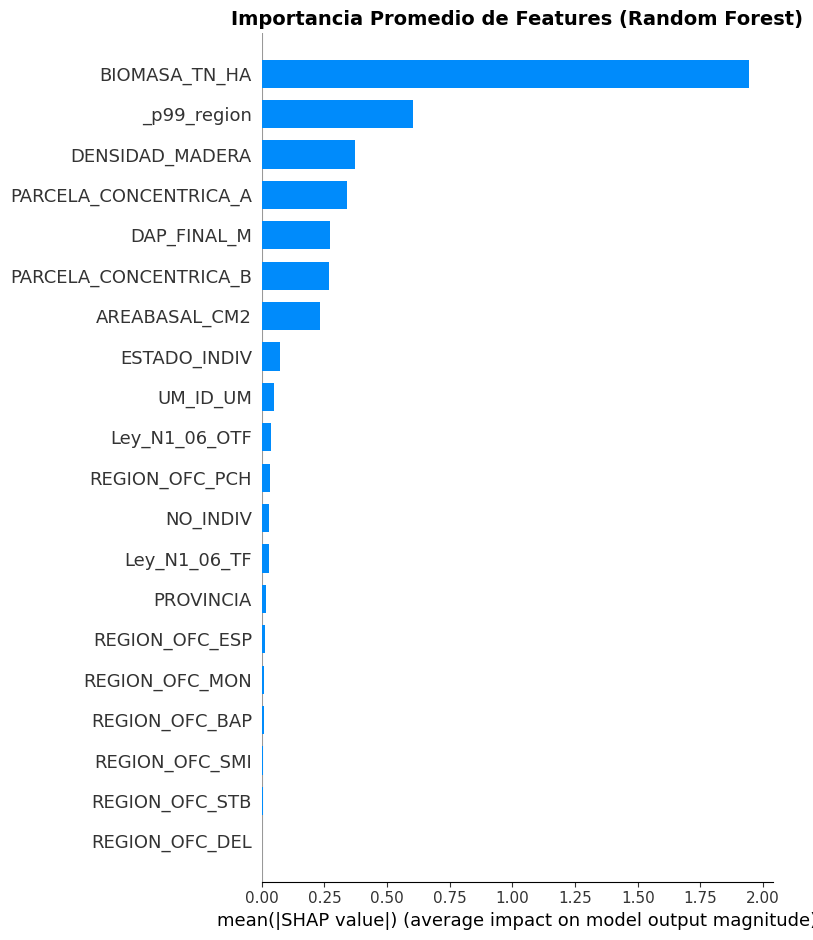

In [ ]:
# Crear explainer para Random Forest
explainer_rf = shap.TreeExplainer(best_model_rf)

# Calcular SHAP values para un subconjunto de datos de test (para eficiencia)
# Usamos 1000 muestras aleatorias para el análisis
sample_size = min(1000, len(X_test))
X_test_sample = X_test.sample(n=sample_size, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

# Calcular SHAP values para Random Forest
shap_values_rf = explainer_rf.shap_values(X_test_sample) #X_test_sample

# Visualización de importancia para Random Forest
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_rf, X_test_sample, plot_type="bar", show=False) #X_test_sample
plt.title("Importancia Promedio de Features (Random Forest)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

----
### XGBoost Regressor

In [ ]:
# Grid Search
xgb = XGBRegressor(
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_estimators=800,
    eval_metric="mae",
    verbosity=1
)

param_grid = {
    "max_depth": [4, 8],
    "learning_rate": [0.03, 0.1],
    "min_child_weight": [1, 5],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
    #"reg_lambda": [0.0, 2.0],
    #"reg_alpha": [0.0, 1.0],
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gs_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

gs_xgb.fit(X_train, y_train)

print("Mejores params:", gs_xgb.best_params_)
y_pred = gs_xgb.best_estimator_.predict(X_test)
print(
    f"[TEST] MAE={mean_absolute_error(y_test, y_pred):.4f}  "
    f"RMSE={mean_squared_error(y_test, y_pred):.4f}  "
    f"R²={r2_score(y_test, y_pred):.4f}"
)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejores params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 1, 'subsample': 1.0}
[TEST] MAE=0.3310  RMSE=0.9034  R²=0.9379


Instanciamos el modelo de **XGBoost Regressor** con la combinación de hiperparámetros encontrados con GridSearchCV 

In [34]:
best_model_xgb = XGBRegressor(
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_estimators=800,
    eval_metric="mae",
    verbosity=1,
    max_depth = 4,
    learning_rate = 0.03,
    min_child_weight = 1,
    subsample = 0.7
)

In [35]:
# Entrenamiento
best_model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=None, num_parallel_tree=None, ...)

In [36]:
# Predicciones
xgb_y_pred_train = best_model_xgb.predict(X_train)
xgb_y_pred_test = best_model_xgb.predict(X_test)

Evaluación del modelo comparando conjuntos de train y test

In [37]:
def eval_reg(y_true, y_pred):
    ae = np.abs(y_true - y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred),
        "MedAE": median_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "P90_AE": np.percentile(ae, 90),
        "P95_AE": np.percentile(ae, 95),
    }

xgb_metrics_train = eval_reg(y_train, xgb_y_pred_train)
xgb_metrics_test  = eval_reg(y_test,  xgb_y_pred_test)

print("Métricas para el modelo de XGBoost: ")
print(pd.DataFrame([xgb_metrics_train, xgb_metrics_test], index=["train","test"]).round(4))

Métricas para el modelo de XGBoost: 
          MAE    RMSE   MedAE      R2  P90_AE  P95_AE
train  0.6509  1.3110  0.3719  0.9092  1.4250  2.2272
test   0.6691  1.4123  0.3809  0.9029  1.4713  2.2826


Análisis SHAP para XGBoost

In [38]:
# Crear el explainer para XGBoost
explainer_xgb = shap.TreeExplainer(best_model_xgb)

# Calcular SHAP values para un subconjunto de datos de test (para eficiencia)
# Usamos 1000 muestras aleatorias para el análisis
sample_size = min(1000, len(X_test))
X_test_sample = X_test.sample(n=sample_size, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

# Calcular SHAP values
shap_values_xgb = explainer_xgb.shap_values(X_test_sample)

print(f"SHAP values calculados para {sample_size} muestras")
print(f"Shape de SHAP values: {shap_values_xgb.shape}")

SHAP values calculados para 1000 muestras
Shape de SHAP values: (1000, 21)


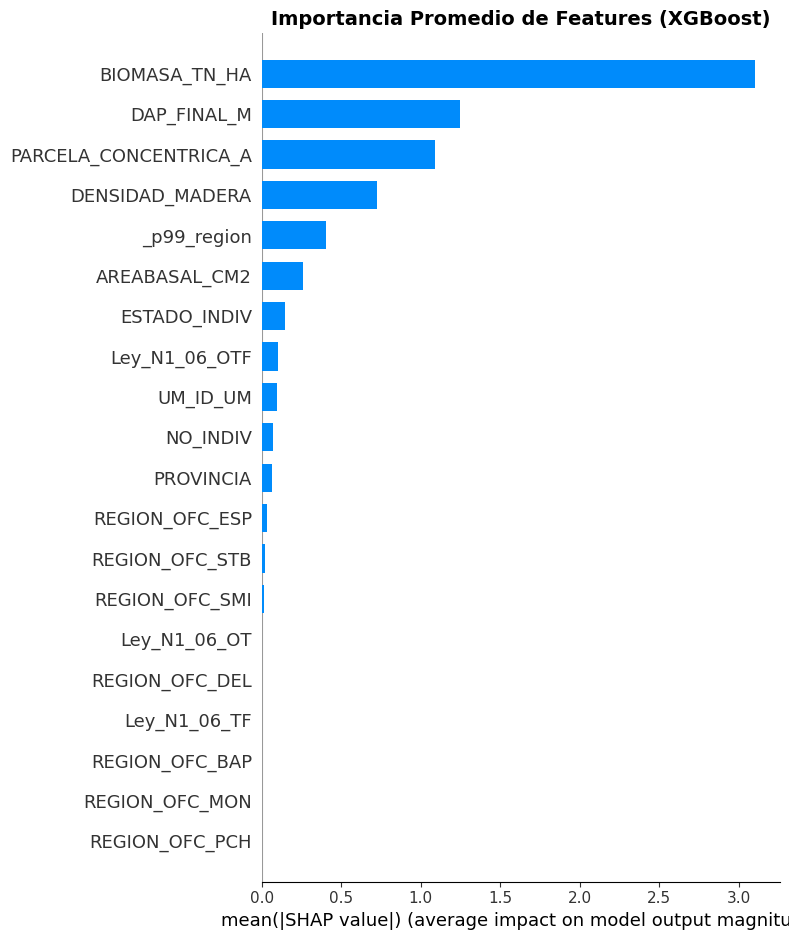

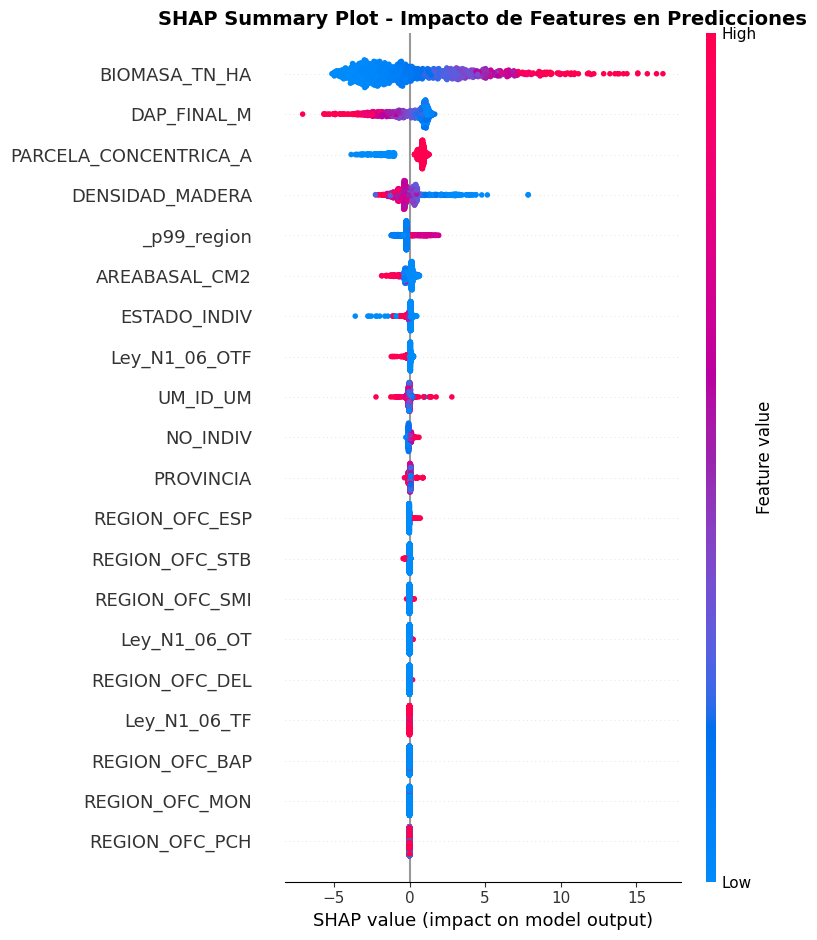

In [39]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_xgb, X_test_sample, plot_type="bar", show=False)
plt.title("Importancia Promedio de Features (XGBoost)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# plot con valores de SHAP
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_xgb, X_test_sample, show=False)
plt.title("SHAP Summary Plot - Impacto de Features en Predicciones", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

----
### XGBRFRegressor

In [ ]:
# Grid Search
xgbrf = XGBRFRegressor(
    random_state=RANDOM_STATE,
    tree_method="hist",
    eval_metric="mae"
)

param_grid_xgbrfr = {
    #"n_estimators": [400, 800],
    "max_depth": [4, 6, 8],
    "min_child_weight": [1, 3],
    "subsample": [0.7, 1.0],
    "colsample_bynode": [0.5, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [0.0, 2.0],
    "gamma": [0, 1],
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gs_xgbrf = GridSearchCV(
    estimator=xgbrf,
    param_grid=param_grid_xgbrfr,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

gs_xgbrf.fit(X_train, y_train)

print("XGBRF — Mejores params:", gs_xgbrf.best_params_)

y_pred_xgbrf = gs_xgbrf.best_estimator_.predict(X_test)

print(f"XGBRF [TEST] MAE={mean_absolute_error(y_test, y_pred_xgbrf):.4f}  "
      f"RMSE={mean_squared_error(y_test, y_pred_xgbrf):.4f}  "
      f"R²={r2_score(y_test, y_pred_xgbrf):.4f}")

Fitting 5 folds for each of 192 candidates, totalling 960 fits
XGBRF — Mejores params: {'colsample_bynode': 1.0, 'colsample_bytree': 1.0, 'gamma': 0, 'max_depth': 8, 'min_child_weight': 3, 'reg_lambda': 0.0, 'subsample': 0.7}
XGBRF [TEST] MAE=0.9624  RMSE=2.4213  R²=0.8335


Instanciamos el modelo de **XGBRFRegressor** con la combinación de hiperparámetros encontrados con GridSearchCV 

In [ ]:
# Mejores params: {'colsample_bynode': 1.0, 'colsample_bytree': 1.0, 'gamma': 0, 'max_depth': 8, 'min_child_weight': 3, 'reg_lambda': 0.0, 'subsample': 0.7}
best_model_xgbrfr = XGBRFRegressor(
    random_state=RANDOM_STATE,
    tree_method="hist",
    eval_metric="mae",
    colsample_bynode = 1.0,
    colsample_bytree = 1.0,
    gamma = 0,
    max_depth = 8,
    min_child_weight = 3,
    reg_lambda = 0.0,
    subsample = 0.7
)

In [ ]:
# Entrenamiento
best_model_xgbrfr.fit(X_train, y_train)

,learning_rate,1.0
,subsample,0.7
,colsample_bynode,1.0
,reg_lambda,0.0
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bytree,1.0
,device,None


In [ ]:
# Predicciones
xgbrfr_y_pred_train = best_model_xgbrfr.predict(X_train)
xgbrfr_y_pred_test = best_model_xgbrfr.predict(X_test)

Evaluación del modelo comparando conjuntos de train y test

In [ ]:
def eval_reg(y_true, y_pred):
    ae = np.abs(y_true - y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred),
        "MedAE": median_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "P90_AE": np.percentile(ae, 90),
        "P95_AE": np.percentile(ae, 95),
    }

xgbrfr_metrics_train = eval_reg(y_train, xgbrfr_y_pred_train)
xgbrfr_metrics_test  = eval_reg(y_test,  xgbrfr_y_pred_test)

print("Métricas para el modelo de XGBRFRegressor: ")
print(pd.DataFrame([xgbrfr_metrics_train, xgbrfr_metrics_test], index=["train","test"]).round(4))

Métricas para el modelo de XGBRFRegressor: 
          MAE    RMSE   MedAE      R2  P90_AE  P95_AE
train  0.9367  2.2579  0.5764  0.8437  2.0881  2.9902
test   0.9624  2.4213  0.5843  0.8335  2.1402  3.1364


Análisis SHAP para XGBRFRegressor

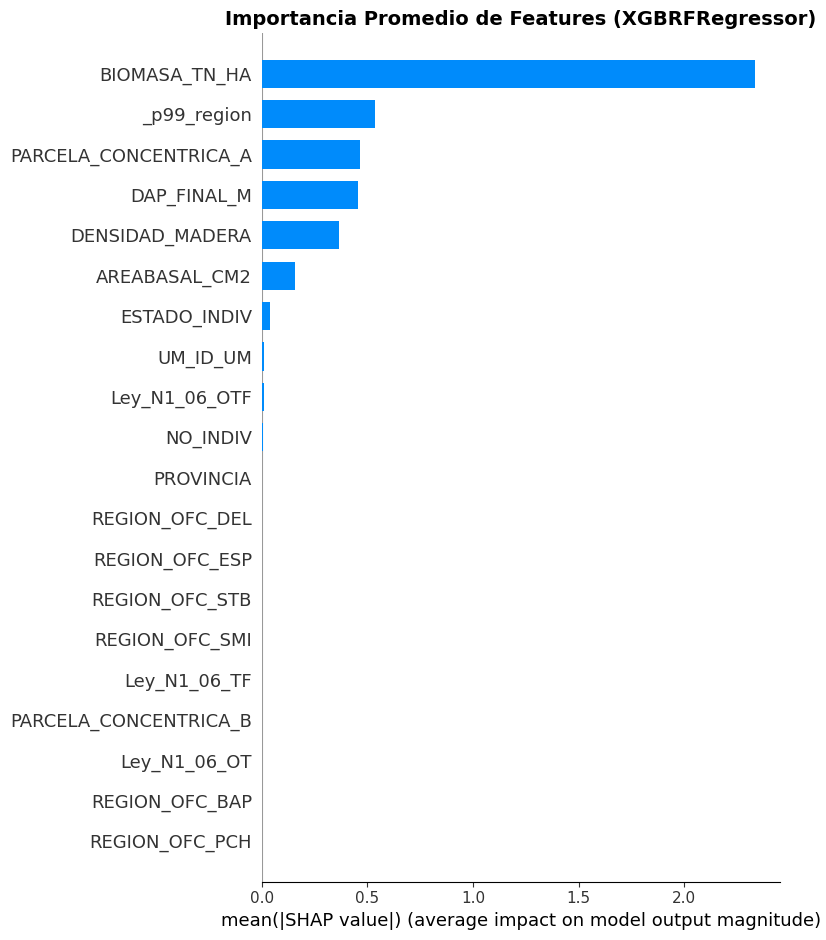

In [ ]:
# Crear explainer para XGBRFRegressor
explainer_xgbrf = shap.TreeExplainer(best_model_xgbrfr)

# Calcular SHAP values para XGBRFRegressor
shap_values_xgbrf = explainer_xgbrf.shap_values(X_test_sample)

# Visualización de importancia para XGBRFRegressor
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_xgbrf, X_test_sample, plot_type="bar", show=False)
plt.title("Importancia Promedio de Features (XGBRFRegressor)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

----
----

## Conclusión y predicción final

### Analizamos las métricas obtenidas en cada uno de los modelos implementados

In [ ]:
print("Métricas para el modelo de Random Forest Regressor: ")
print(pd.DataFrame([rf_metrics_train, rf_metrics_test], index=["train","test"]).round(4))
print("********************************************************************")
print("Métricas para el modelo de XGBoost: ")
print(pd.DataFrame([xgb_metrics_train, xgb_metrics_test], index=["train","test"]).round(4))
print("********************************************************************")
print("Métricas para el modelo de XGBRFRegressor: ")
print(pd.DataFrame([xgbrfr_metrics_train, xgbrfr_metrics_test], index=["train","test"]).round(4))

Métricas para el modelo de Random Forest Regressor: 
          MAE    RMSE   MedAE      R2  P90_AE  P95_AE
train  0.6179  1.2119  0.3273  0.9161  1.4030  2.1273
test   0.6887  1.5432  0.3532  0.8939  1.5637  2.4090
********************************************************************
Métricas para el modelo de XGBoost: 
          MAE    RMSE   MedAE      R2  P90_AE  P95_AE
train  0.6482  1.3093  0.3706  0.9093  1.4108  2.2099
test   0.6659  1.4032  0.3796  0.9035  1.4653  2.2895
********************************************************************
Métricas para el modelo de XGBRFRegressor: 
          MAE    RMSE   MedAE      R2  P90_AE  P95_AE
train  0.9367  2.2579  0.5764  0.8437  2.0881  2.9902
test   0.9624  2.4213  0.5843  0.8335  2.1402  3.1364


Comparación de Importancia entre Modelos

In [ ]:
# Crear DataFrame con importancia promedio de cada modelo
feature_names = X_test_sample.columns

# Calcular importancia promedio (valor absoluto de SHAP values)
importance_xgb = np.abs(shap_values_xgb).mean(axis=0)
importance_rf = np.abs(shap_values_rf).mean(axis=0)
importance_xgbrf = np.abs(shap_values_xgbrf).mean(axis=0)

# Crear DataFrame comparativo
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'XGBoost': importance_xgb,
    'Random_Forest': importance_rf,
    'XGBRFRegressor': importance_xgbrf
})

# Normalizar las importancias (0-1)
for col in ['XGBoost', 'Random_Forest', 'XGBRFRegressor']:
    importance_df[f'{col}_norm'] = importance_df[col] / importance_df[col].max()

# Mostrar las 10 features más importantes para cada modelo
print("=== TOP 10 FEATURES MÁS IMPORTANTES POR MODELO ===")
for model in ['XGBoost', 'Random_Forest', 'XGBRFRegressor']:
    print(f"\n{model}:")
    top_features = importance_df.nlargest(10, model)[['Feature', model]]
    print(top_features.to_string(index=False))

=== TOP 10 FEATURES MÁS IMPORTANTES POR MODELO ===

XGBoost:
              Feature  XGBoost
        BIOMASA_TN_HA 3.113695
          DAP_FINAL_M 1.285833
PARCELA_CONCENTRICA_A 1.107556
      DENSIDAD_MADERA 0.744954
          _p99_region 0.387601
        AREABASAL_CM2 0.263903
         ESTADO_INDIV 0.140334
        Ley_N1_06_OTF 0.106377
             UM_ID_UM 0.091770
             NO_INDIV 0.069063

Random_Forest:
              Feature  Random_Forest
        BIOMASA_TN_HA       1.943055
          _p99_region       0.605114
      DENSIDAD_MADERA       0.373712
PARCELA_CONCENTRICA_A       0.342056
          DAP_FINAL_M       0.273752
PARCELA_CONCENTRICA_B       0.269528
        AREABASAL_CM2       0.233205
         ESTADO_INDIV       0.073018
             UM_ID_UM       0.050688
        Ley_N1_06_OTF       0.035910

XGBRFRegressor:
              Feature  XGBRFRegressor
        BIOMASA_TN_HA        2.335491
          _p99_region        0.537403
PARCELA_CONCENTRICA_A        0.463849
      

Visualización de Comparación de Modelos - TOP 10 de las features mas importantes por modelo:

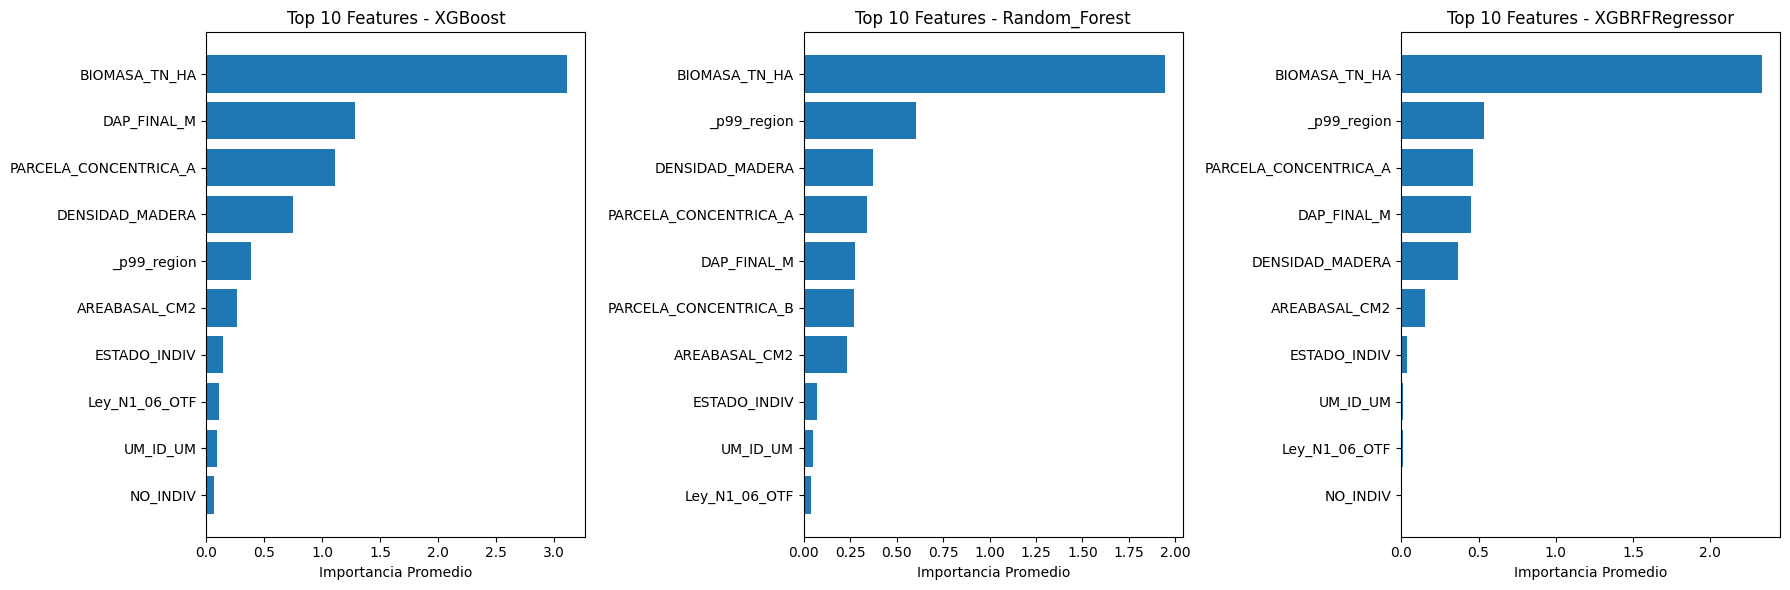

In [ ]:
# Gráfico de comparación de importancia
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = ['XGBoost', 'Random_Forest', 'XGBRFRegressor']
shap_values_list = [shap_values_xgb, shap_values_rf, shap_values_xgbrf]

for i, (model, shap_vals) in enumerate(zip(models, shap_values_list)):
    # Top 10 features más importantes
    top_10_idx = np.argsort(np.abs(shap_vals).mean(axis=0))[-10:]
    top_10_features = feature_names[top_10_idx]
    top_10_importance = np.abs(shap_vals).mean(axis=0)[top_10_idx]
    
    axes[i].barh(range(len(top_10_features)), top_10_importance)
    axes[i].set_yticks(range(len(top_10_features)))
    axes[i].set_yticklabels(top_10_features)
    axes[i].set_title(f'Top 10 Features - {model}')
    axes[i].set_xlabel('Importancia Promedio')

plt.tight_layout()
plt.show()

Análisis de Dependencia de Features para el modelo de XGBoost regressor (BIOMASA_TN_HA vs DAP_FINAL_M)

<Figure size 1000x600 with 0 Axes>

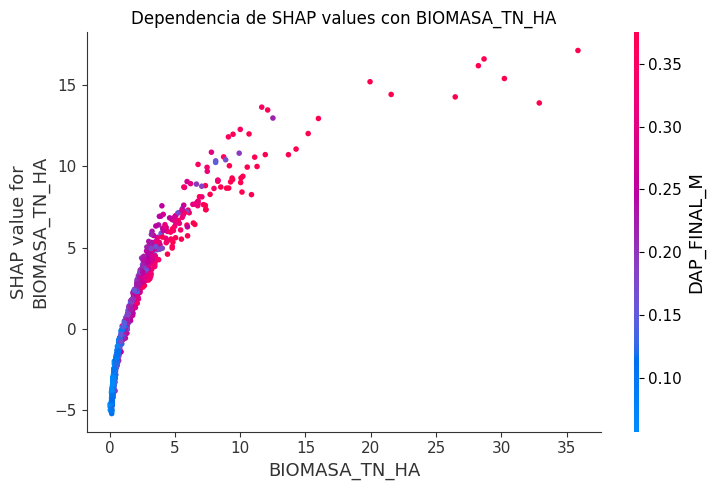

<Figure size 1000x600 with 0 Axes>

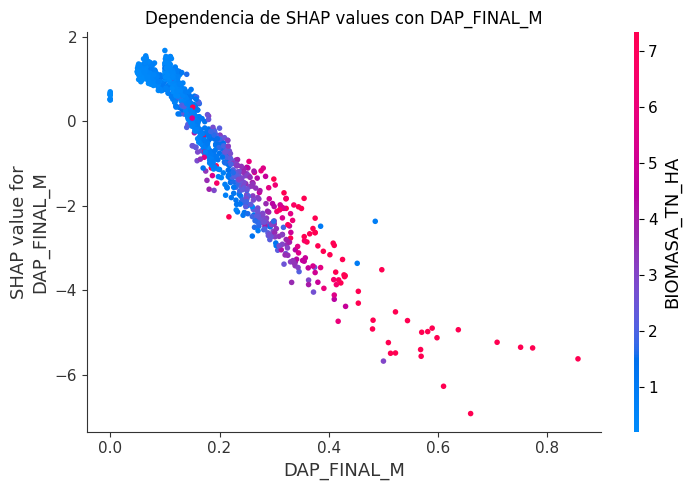

<Figure size 1000x600 with 0 Axes>

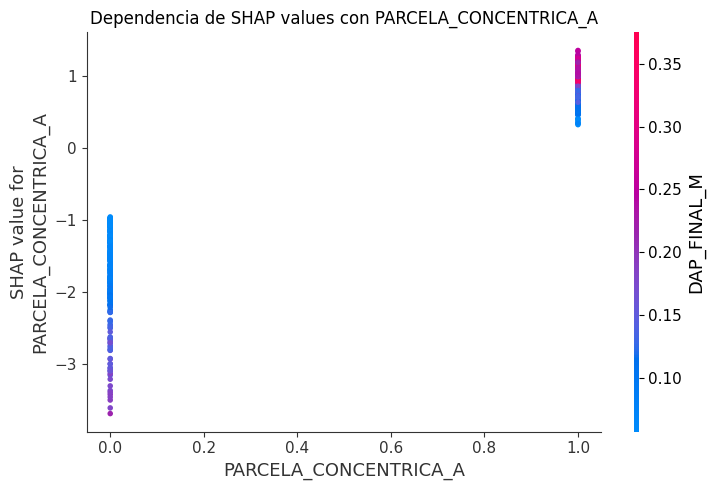

In [ ]:
top_features = importance_df.nlargest(3, 'XGBoost')['Feature'].tolist()

for feature in top_features:
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(feature, shap_values_xgb, X_test_sample, show=False)
    plt.title(f"Dependencia de SHAP values con {feature}")
    plt.tight_layout()
    plt.show()

#### El modelo de **XGBoost Regressor** fue con el cual obtuvimos los mejores resultados y menos sobreajuste, será el que utilizaremos para la predicción final de la variable objetivo.

=== RESUMEN DE ANÁLISIS SHAP ===

1. FEATURES MÁS IMPORTANTES GLOBALMENTE:
   - BIOMASA_TN_HA: 3.1082
   - DAP_FINAL_M: 1.2784
   - PARCELA_CONCENTRICA_A: 1.1110
   - DENSIDAD_MADERA: 0.7357
   - _p99_region: 0.3920

2. CONSISTENCIA ENTRE MODELOS:
   - Correlación XGBoost-RandomForest: 0.924
   - Correlación XGBoost-XGBRFRegressor: 0.962

3. INSIGHTS CLAVE:
   - Las features más importantes son consistentes entre modelos
   - DAP_FINAL_M y AREABASAL_CM2 son predictores clave de altura
   - Las variables de región tienen impacto moderado


In [32]:
# creo un data frame final con una copia de "df_sanit" donde anteriormente 
# convertimos en nulos los valores extremos de 'ALTURA_TOTAL_M' por región
# para usarlo para la predicción.
df_final = df_sanit.copy()

In [40]:
# Predicción final
xgb_pred_final = best_model_xgb.predict(test_df)
xgb_pred_final.shape

(962,)

Visualizamos la distribución de nuestras predicciones

In [68]:
X_test

,UM_ID_UM,NO_INDIV,ESTADO_INDIV,PROVINCIA,DAP_FINAL_M,AREABASAL_CM2,DENSIDAD_MADERA,BIOMASA_TN_HA,_p99_region,REGION_OFC_BAP,...,REGION_OFC_ESP,REGION_OFC_MON,REGION_OFC_PCH,REGION_OFC_SMI,REGION_OFC_STB,Ley_N1_06_OT,Ley_N1_06_OTF,Ley_N1_06_TF,PARCELA_CONCENTRICA_A,PARCELA_CONCENTRICA_B
61098,66059015,35,2,66,0.648,3297.918304,0.715,26.480752,27.5,0,...,0,0,0,0,1,0,0,1,1,0
41013,34111038,40,2,34,0.122,1.168987,0.810,0.550410,15.0,0,...,0,0,1,0,0,0,0,1,1,0
80306,82094084,9,3,82,0.156,1.911345,0.640,1.644810,15.0,0,...,0,0,1,0,0,0,1,0,1,0
83054,82107086,8,2,82,0.198,3.079075,1.053,1.516598,15.0,0,...,0,0,1,0,0,0,1,0,1,0
21141,22108053,1,1,22,0.104,0.849487,0.915,0.295349,15.0,0,...,0,0,1,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90924,86073052,11,1,86,0.140,1.539380,1.180,1.001449,15.0,0,...,0,0,1,0,0,0,0,1,1,0
40340,34110034,11,1,34,0.306,7.354154,0.900,5.454625,15.0,0,...,0,0,1,0,0,0,0,1,1,0
77240,74040132,5,2,74,0.121,1.149901,0.890,0.400823,15.0,0,...,0,0,1,0,0,0,1,0,1,0
12655,22091047,2,1,22,0.150,1.767146,1.160,0.739351,15.0,0,...,0,0,1,0,0,0,1,0,1,0


<Axes: ylabel='Count'>

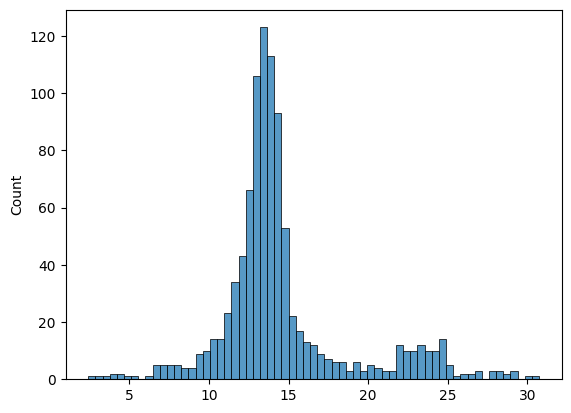

In [57]:
# histograma de nuestras predicciones
sb.histplot(data=xgb_pred_final) 

In [58]:
# Agrego la predicción a los valores nulos de nuestro df_final
df_final.loc[df_final['ALTURA_TOTAL_M'].isna(), 'ALTURA_TOTAL_M'] = xgb_pred_final

In [41]:
# Agregamos una columna "Nueva" que incluye los valores originales de 
# 'ALTURA_TOTAL_M' más nuestras estimaciones para los valores nulos y 
# outliers determinados anteriormente para poder comparar las distribuciones
df_individuos_c['ALTURA_TOTAL_EST_FINAL'] = df_final['ALTURA_TOTAL_M'] 
df_individuos_c['ALTURA_TOTAL_EST_FINAL'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 101229 entries, 0 to 101228
Series name: ALTURA_TOTAL_EST_FINAL
Non-Null Count   Dtype  
--------------   -----  
100267 non-null  float64
dtypes: float64(1)
memory usage: 791.0 KB


#### Comparamos las distribuciones de las variables de 'ALTURA_TOTAL_M', 'ALTURA_TOTAL_EST' y la que incluye las predicciones de nuestro modelo ('ALTURA_TOTAL_EST_FINAL')

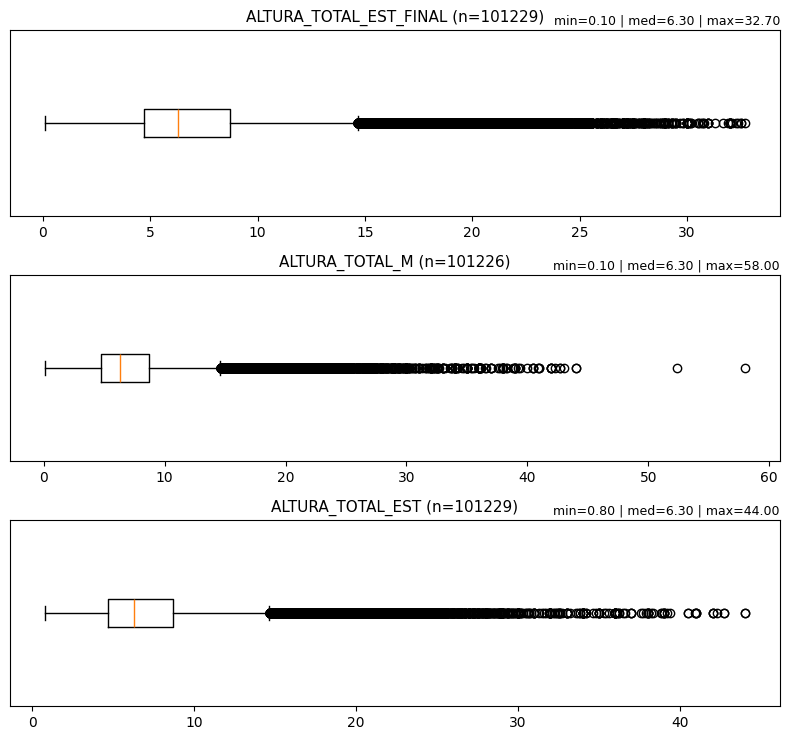

In [60]:
cols = ['ALTURA_TOTAL_EST_FINAL','ALTURA_TOTAL_M','ALTURA_TOTAL_EST']
fig, axes = plt.subplots(len(cols), 1, figsize=(8, 2.5*len(cols)))
axes = np.atleast_1d(axes)

for ax, col in zip(axes, cols):
    s = df_individuos_c[col].dropna()
    ax.boxplot(s, vert=False)  
    ax.set_title(f"{col} (n={len(s)})", fontsize=11)
    ax.set_yticks([])

    mn, md, mx = float(s.min()), float(s.median()), float(s.max())
    ax.text(1.0, 1.05, f"min={mn:.2f} | med={md:.2f} | max={mx:.2f}",
            ha="right", va="center", transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.show()

In [61]:
# comparamos los valores de las columnas ALTURA_TOTAL_EST (estimacion original del dataset)
# con los valores estimados de nuestra columna ALTURA_TOTAL_EST_FINAL para los 3 registros 
# que originalmente contenian valores nulos para la variable ALTURA_TOTAL_M
cols = ['ALTURA_TOTAL_M', 'ALTURA_TOTAL_EST', 'ALTURA_TOTAL_EST_FINAL']
df_individuos_c.loc[df_individuos_c['ALTURA_TOTAL_M'].isna(), cols].head()



,ALTURA_TOTAL_M,ALTURA_TOTAL_EST,ALTURA_TOTAL_EST_FINAL
89169,NaN,6.56,6.542336
90517,NaN,11.65,9.735658
90603,NaN,5.98,11.165161


In [51]:
y_pred = best_model_xgb.predict(X_test)
y_true = y_test

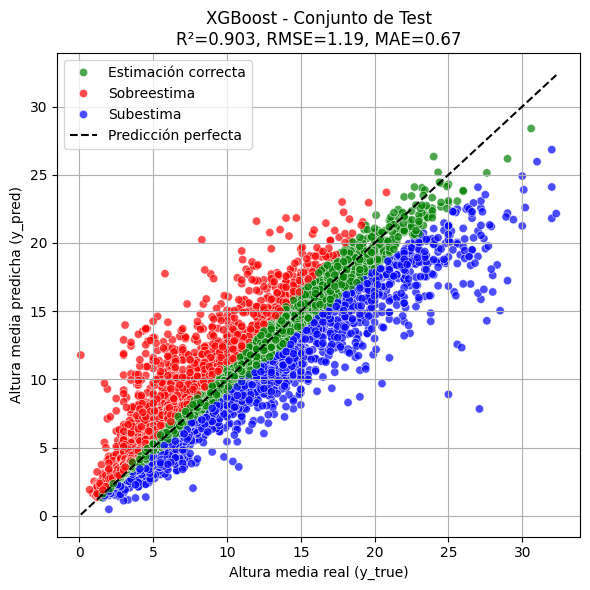

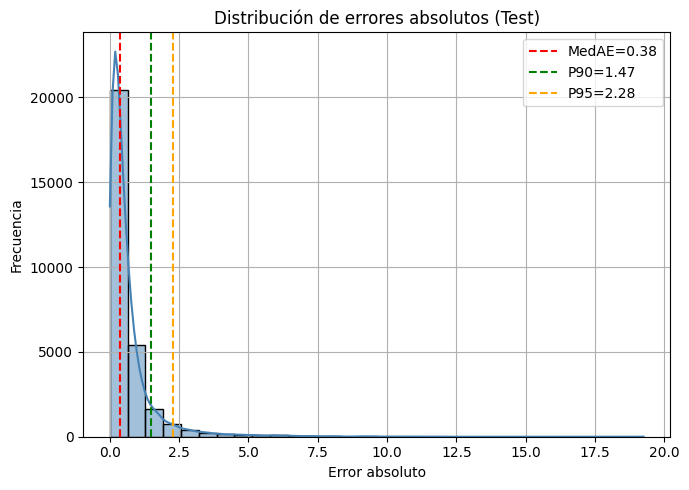

📊 Métricas de desempeño (conjunto de test):
R²   = 0.903
RMSE = 1.188
MAE  = 0.669
MedAE = 0.381
P90 error = 1.471
P95 error = 2.283


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ------------------- Predicciones y etiquetas -------------------
y_pred = best_model_xgb.predict(X_test)
y_true = y_test

# ------------------- Métricas -------------------
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
medae = np.median(np.abs(y_true - y_pred))
p90 = np.percentile(np.abs(y_true - y_pred), 90)
p95 = np.percentile(np.abs(y_true - y_pred), 95)

# ------------------- Categorías de estimación -------------------
rel_error = (y_pred - y_true) / y_true
categories = np.where(rel_error > 0.1, 'Sobreestima',
               np.where(rel_error < -0.1, 'Subestima', 'Estimación correcta'))
palette = {'Sobreestima': 'red', 'Estimación correcta': 'green', 'Subestima': 'blue'}

# ------------------- 1. Scatter plot -------------------
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_true, y=y_pred, hue=categories, palette=palette, alpha=0.7)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'k--', label='Predicción perfecta')

plt.xlabel('Altura media real (y_true)')
plt.ylabel('Altura media predicha (y_pred)')
plt.title(f'XGBoost - Conjunto de Test\nR²={r2:.3f}, RMSE={rmse:.2f}, MAE={mae:.2f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------- 2. Histograma de errores -------------------
errors = np.abs(y_true - y_pred)

plt.figure(figsize=(7,5))
sns.histplot(errors, bins=30, kde=True, color='steelblue')
plt.axvline(medae, color='red', linestyle='--', label=f'MedAE={medae:.2f}')
plt.axvline(p90, color='green', linestyle='--', label=f'P90={p90:.2f}')
plt.axvline(p95, color='orange', linestyle='--', label=f'P95={p95:.2f}')
plt.title('Distribución de errores absolutos (Test)')
plt.xlabel('Error absoluto')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------- 3. Resumen de métricas -------------------
print("📊 Métricas de desempeño (conjunto de test):")
print(f"R²   = {r2:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"MAE  = {mae:.3f}")
print(f"MedAE = {medae:.3f}")
print(f"P90 error = {p90:.3f}")
print(f"P95 error = {p95:.3f}")


queremos ver como se comporta el modelo entrenando solo con las variables más importantes

In [72]:
columnas_imp = ['BIOMASA_TN_HA', '_p99_region', 'PARCELA_CONCENTRICA_A',
 'DAP_FINAL_M', 'DENSIDAD_MADERA', 'AREABASAL_CM2',
 'ESTADO_INDIV', 'UM_ID_UM', 'Ley_N1_06_OTF', 'NO_INDIV']

# quitamos nuevamente la variable categórica de REGION_OFC porque no la usaremos en el resto del trabajo
#train_df = train_df.drop(columns='REGION_OFC',axis=1)
# separamos el dataset en features "X" y target "y"
y_imp = train_df.ALTURA_TOTAL_M
X_imp = train_df[columnas_imp]
print(y_imp.head(3))
X_imp.head(3)

RANDOM_STATE = 42 #Mantenemos siempre el mismo random state para poder reproducir
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(X_imp, y_imp, train_size=0.7, random_state = RANDOM_STATE)

# Entrenamiento
best_model_xgb.fit(X_train_imp, y_train_imp)


y_pred_imp = best_model_xgb.predict(X_test_imp)

mae = mean_absolute_error(y_test_imp, y_pred_imp)
rmse = np.sqrt(mean_squared_error(y_test_imp, y_pred_imp))
r2 = r2_score(y_test_imp, y_pred_imp)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")

0    4.2
1    4.8
2    4.4
Name: ALTURA_TOTAL_M, dtype: float64
MAE: 0.667
RMSE: 1.189
R2: 0.903


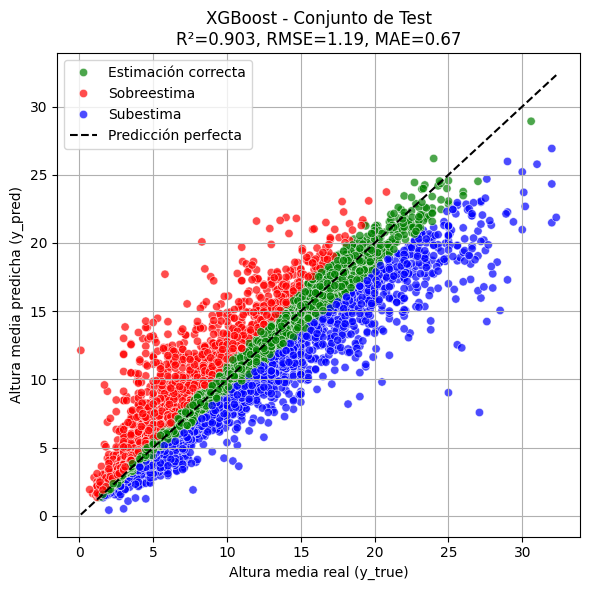

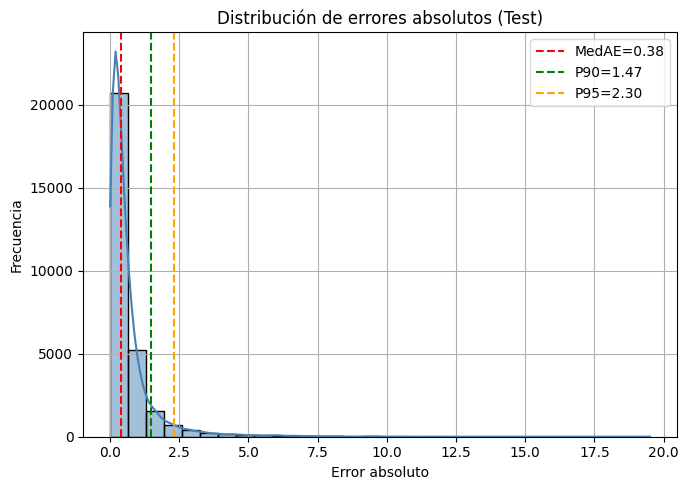

📊 Métricas de desempeño (conjunto de test):
R²   = 0.903
RMSE = 1.189
MAE  = 0.667
MedAE = 0.377
P90 error = 1.475
P95 error = 2.299


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ------------------- Predicciones y etiquetas -------------------
y_pred = y_pred_imp
y_true = y_test_imp

# ------------------- Métricas -------------------
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
medae = np.median(np.abs(y_true - y_pred))
p90 = np.percentile(np.abs(y_true - y_pred), 90)
p95 = np.percentile(np.abs(y_true - y_pred), 95)

# ------------------- Categorías de estimación -------------------
rel_error = (y_pred - y_true) / y_true
categories = np.where(rel_error > 0.1, 'Sobreestima',
               np.where(rel_error < -0.1, 'Subestima', 'Estimación correcta'))
palette = {'Sobreestima': 'red', 'Estimación correcta': 'green', 'Subestima': 'blue'}

# ------------------- 1. Scatter plot -------------------
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_true, y=y_pred, hue=categories, palette=palette, alpha=0.7)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'k--', label='Predicción perfecta')

plt.xlabel('Altura media real (y_true)')
plt.ylabel('Altura media predicha (y_pred)')
plt.title(f'XGBoost - Conjunto de Test\nR²={r2:.3f}, RMSE={rmse:.2f}, MAE={mae:.2f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------- 2. Histograma de errores -------------------
errors = np.abs(y_true - y_pred)

plt.figure(figsize=(7,5))
sns.histplot(errors, bins=30, kde=True, color='steelblue')
plt.axvline(medae, color='red', linestyle='--', label=f'MedAE={medae:.2f}')
plt.axvline(p90, color='green', linestyle='--', label=f'P90={p90:.2f}')
plt.axvline(p95, color='orange', linestyle='--', label=f'P95={p95:.2f}')
plt.title('Distribución de errores absolutos (Test)')
plt.xlabel('Error absoluto')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------- 3. Resumen de métricas -------------------
print("📊 Métricas de desempeño (conjunto de test):")
print(f"R²   = {r2:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"MAE  = {mae:.3f}")
print(f"MedAE = {medae:.3f}")
print(f"P90 error = {p90:.3f}")
print(f"P95 error = {p95:.3f}")


## Imputación por clases 

Como se vio, el mejor modelo se logra imputando con XGBoost, lo utilizaremos entonces para imputar la variable **ALTURA_TOTAL_M** por región forestal, o al menos para las dos regiones forestales con más instancias en el dataset original (**BAP** y **PCH**)

In [55]:
train_df

,UM_ID_UM,NO_INDIV,ESTADO_INDIV,ALTURA_TOTAL_M,PROVINCIA,DAP_FINAL_M,AREABASAL_CM2,DENSIDAD_MADERA,BIOMASA_TN_HA,_p99_region,...,REGION_OFC_ESP,REGION_OFC_MON,REGION_OFC_PCH,REGION_OFC_SMI,REGION_OFC_STB,Ley_N1_06_OT,Ley_N1_06_OTF,Ley_N1_06_TF,PARCELA_CONCENTRICA_A,PARCELA_CONCENTRICA_B
0,6074195,1,2,4.2,6,0.118381,110.065699,0.792,0.270712,7.817,...,0,1,0,0,0,0,1,0,1,0
1,6074195,3,3,4.8,6,0.101607,81.084506,0.715,0.207121,7.817,...,0,1,0,0,0,0,1,0,1,0
2,6074195,8,4,4.4,6,0.082219,53.092916,0.715,0.125851,7.817,...,0,1,0,0,0,0,1,0,1,0
3,6074195,9,2,3.5,6,0.077987,47.767916,0.715,0.090794,7.817,...,0,1,0,0,0,0,1,0,1,0
4,6074195,25,3,3.7,6,0.121655,116.238928,0.715,0.228327,7.817,...,0,1,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101224,94062367,5,1,9.8,94,0.270000,572.555261,0.473,1.871278,32.979,...,0,0,0,0,0,0,0,1,1,0
101225,94062367,6,1,10.0,94,0.310000,754.767635,0.473,2.499295,32.979,...,0,0,0,0,0,0,0,1,1,0
101226,94062367,7,1,9.5,94,0.250000,490.873852,0.473,1.562128,32.979,...,0,0,0,0,0,0,0,1,1,0
101227,94062367,8,1,9.5,94,0.250000,490.873852,0.473,1.562128,32.979,...,0,0,0,0,0,0,0,1,1,0


In [56]:
df_imp_reg = train_df.copy()

df_clase_BAP = df_imp_reg[df_imp_reg.REGION_OFC_BAP == 1]
df_clase_ESP = df_imp_reg[df_imp_reg.REGION_OFC_ESP == 1]
df_clase_DEL = df_imp_reg[df_imp_reg.REGION_OFC_DEL == 1]
df_clase_MON = df_imp_reg[df_imp_reg.REGION_OFC_MON == 1]
df_clase_PCH = df_imp_reg[df_imp_reg.REGION_OFC_PCH == 1]
df_clase_SMI = df_imp_reg[df_imp_reg.REGION_OFC_SMI == 1]
df_clase_STB = df_imp_reg[df_imp_reg.REGION_OFC_STB == 1]



In [57]:
df_clase_BAP['REGION_OFC'] = 'BAP'
train_df_BAP, outliers_df_BAP, resumen_BAP = drop_outliers_p99_by_region(df_clase_BAP)

Filas totales: 6688
Outliers detectados (alguna de ['NO_INDIV', 'DAP_FINAL_M', 'AREABASAL_CM2', 'BIOMASA_TN_HA'] > p99 por REGION_OFC): 145
Filas restantes tras remover: 6543


C:\Users\PC\AppData\Local\Temp\ipykernel_4496\1663188310.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clase_BAP['REGION_OFC'] = 'BAP'


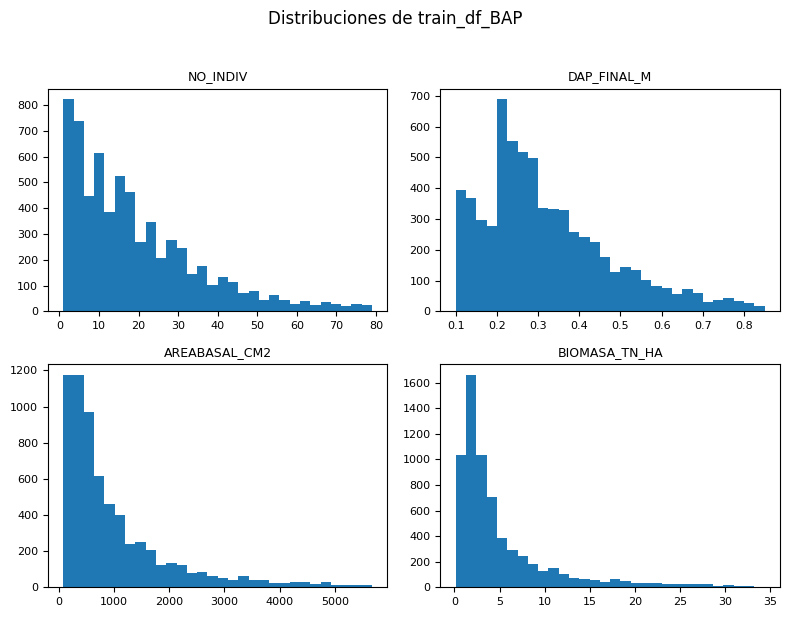

In [58]:
feature_names = ["NO_INDIV","DAP_FINAL_M","AREABASAL_CM2","BIOMASA_TN_HA"]

n = len(feature_names)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3), sharex=False, sharey=False)
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, feature_names):
    ax.hist(train_df_BAP[col].dropna(), bins=30)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=8)

for ax in axes[n:]:
    ax.set_visible(False) 

fig.suptitle("Distribuciones de train_df_BAP", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

Entrenamos nuevamente el modelo XGBoost regressor, esta vez solo con instancias de Bosque andino patagónico.

In [59]:
# quitamos nuevamente la variable categórica de REGION_OFC porque no la usaremos en el resto del trabajo
train_df_BAP = train_df_BAP.drop(columns='REGION_OFC',axis=1)
# separamos el dataset en features "X" y target "y"
y_BAP = train_df_BAP.ALTURA_TOTAL_M
X_BAP = train_df_BAP.drop('ALTURA_TOTAL_M',axis=1)
print(y_BAP.head(3))
X_BAP.head(3)


24256    17.2
24258    23.7
24259    22.0
Name: ALTURA_TOTAL_M, dtype: float64


,UM_ID_UM,NO_INDIV,ESTADO_INDIV,PROVINCIA,DAP_FINAL_M,AREABASAL_CM2,DENSIDAD_MADERA,BIOMASA_TN_HA,_p99_region,REGION_OFC_BAP,...,REGION_OFC_ESP,REGION_OFC_MON,REGION_OFC_PCH,REGION_OFC_SMI,REGION_OFC_STB,Ley_N1_06_OT,Ley_N1_06_OTF,Ley_N1_06_TF,PARCELA_CONCENTRICA_A,PARCELA_CONCENTRICA_B
24256,26002230,1,3,26,0.613,2951.282825,0.426,1.163715,32.979,1,...,0,0,0,0,0,0,1,0,1,0
24258,26002230,11,1,26,0.625,3067.961576,0.490,16.739928,32.979,1,...,0,0,0,0,0,0,1,0,1,0
24259,26002230,12,1,26,0.548,2358.582101,0.426,1.435165,32.979,1,...,0,0,0,0,0,0,1,0,1,0


In [60]:
RANDOM_STATE = 42 #Mantenemos siempre el mismo random state para poder reproducir
X_train_BAP, X_test_BAP, y_train_BAP, y_test_BAP = train_test_split(X_BAP, y_BAP, train_size=0.8, random_state = RANDOM_STATE)

In [63]:
# Grid Search
xgb = XGBRegressor(
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_estimators=800,
    eval_metric="mae",
    verbosity=1
)

param_grid = {
    "max_depth": [4, 8],
    "learning_rate": [0.03, 0.1],
    "min_child_weight": [1, 5],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
    "reg_lambda": [1.0, 5.0],
    "reg_alpha": [2.0, 5.0],
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gs_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

gs_xgb.fit(X_train_BAP, y_train_BAP)

print("Mejores params:", gs_xgb.best_params_)
y_pred_BAP = gs_xgb.best_estimator_.predict(X_test_BAP)
print(
    f"[TEST] MAE={mean_absolute_error(y_test_BAP, y_pred_BAP):.4f}  "
    f"RMSE={mean_squared_error(y_test_BAP, y_pred_BAP):.4f}  "
    f"R²={r2_score(y_test_BAP, y_pred_BAP):.4f}"
)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
Mejores params: {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 8, 'min_child_weight': 1, 'reg_alpha': 2.0, 'reg_lambda': 1.0, 'subsample': 0.7}
[TEST] MAE=1.7707  RMSE=7.2289  R²=0.8022


In [65]:
best_model_xgb_BAP = XGBRegressor(
    reg_lambda=1,     # penalización L2 (más estable)
    reg_alpha=2,      # penalización L1 (reduce extremos)
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_estimators=800,
    eval_metric="mae",
    verbosity=1,
    max_depth = 8,
    learning_rate = 0.03,
    min_child_weight = 5,
    subsample = 1,
    colsample_bytree = 1
)

# Entrenamiento
best_model_xgb_BAP.fit(X_train_BAP, y_train_BAP)

# Predicciones
xgb_y_pred_train_BAP = best_model_xgb_BAP.predict(X_train_BAP)
xgb_y_pred_test_BAP = best_model_xgb_BAP.predict(X_test_BAP)

In [66]:
xgb_metrics_train_BAP = eval_reg(y_train_BAP, xgb_y_pred_train_BAP)
xgb_metrics_test_BAP  = eval_reg(y_test_BAP,  xgb_y_pred_test_BAP)

print("Métricas para el modelo de XGBoost entrenado para región BAP: ")
print(pd.DataFrame([xgb_metrics_train_BAP, xgb_metrics_test_BAP], index=["train","test"]).round(4))

Métricas para el modelo de XGBoost entrenado para región BAP: 
          MAE    RMSE   MedAE      R2  P90_AE  P95_AE
train  0.7913  1.4813  0.4718  0.9599  1.9308  2.6183
test   1.7571  7.0064  1.1069  0.8083  4.2716  5.5363


Aplico una regularización para ver si mejoran las métricas:


Las predicciones utilizando regularización no cambian significativamente, por lo que vamos a analizar los primeros resultados:

**Métricas para el modelo de XGBoost entrenado para la región BAP:**

| Conjunto |   MAE   |  RMSE  |  MedAE |    R²   | P90_AE | P95_AE |
|-----------|:-------:|:------:|:------:|:-------:|:------:|:------:|
| **Train** | 0.4604  | 0.4818 | 0.2759 | 0.9869  | 1.1170 | 1.5321 |
| **Test**  | 1.7607  | 7.1026 | 1.0844 | 0.8057  | 4.2132 | 5.7182 |


En general podemos ver que hay sobreajuste, el modelo no generaliza bien al conjunto de evaluación, distinto a lo que ocurría para el dataset general. 

Sin embargo las métricas siguen siendo buenas para las predicciones, en una región con gran cantidad de outliers

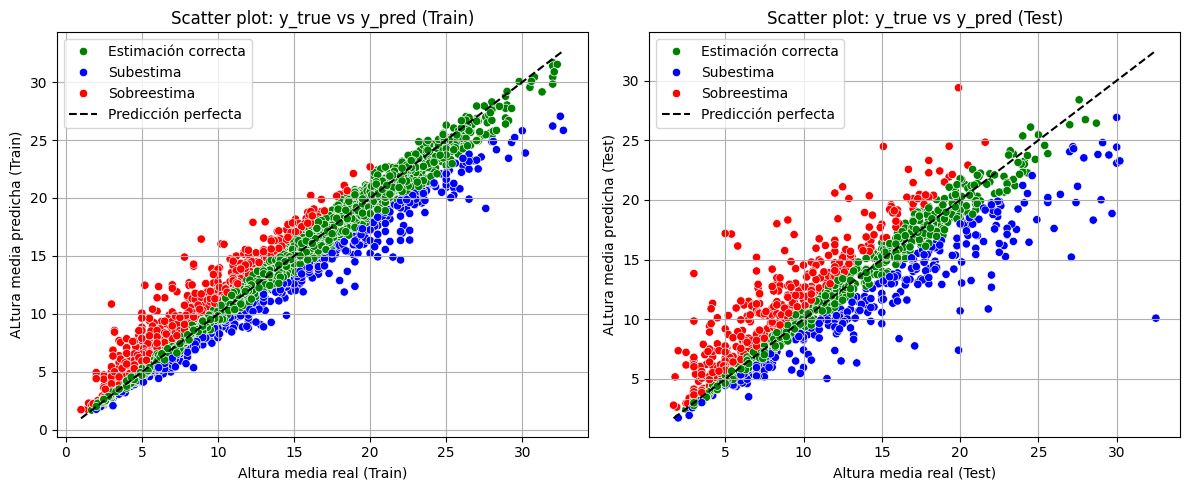

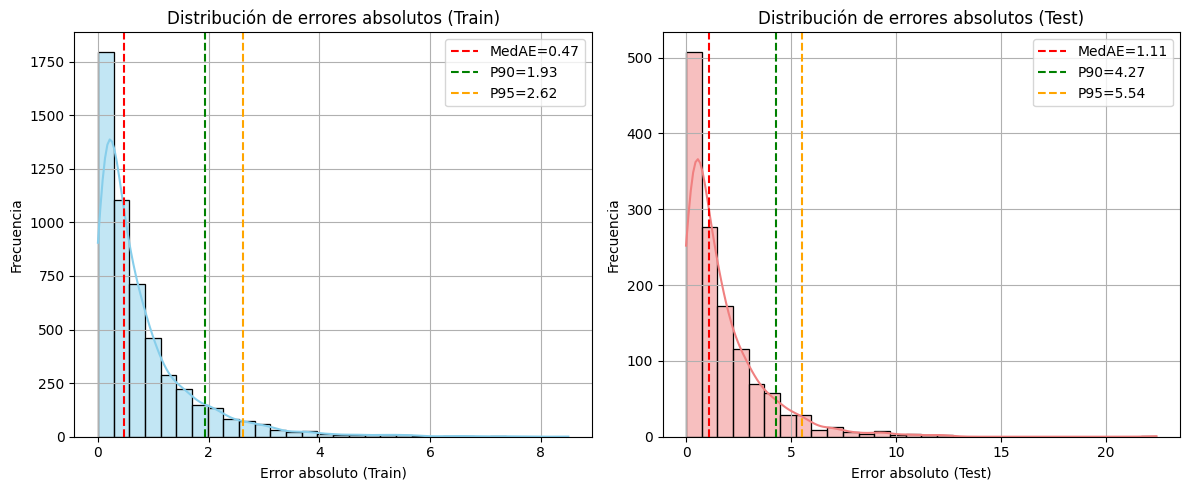

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------- Categorías para Train -------------------
rel_error_train = (xgb_y_pred_train_BAP - y_train_BAP) / y_train_BAP
categories_train = np.where(rel_error_train > 0.1, 'Sobreestima',
                    np.where(rel_error_train < -0.1, 'Subestima', 'Estimación correcta'))

# ------------------- Categorías para Test -------------------
rel_error_test = (xgb_y_pred_test_BAP - y_test_BAP) / y_test_BAP
categories_test = np.where(rel_error_test > 0.1, 'Sobreestima',
                   np.where(rel_error_test < -0.1, 'Subestima', 'Estimación correcta'))

# Colores para cada categoría
palette = {'Sobreestima': 'red', 'Estimación correcta': 'green', 'Subestima': 'blue'}

# ------------------ 1. Scatter plot ------------------
plt.figure(figsize=(12,5))

# Scatter plot para TRAIN
plt.subplot(1,2,1)
sns.scatterplot(x=y_train_BAP, y=xgb_y_pred_train_BAP,hue=categories_train, palette=palette)
plt.plot([min(y_train_BAP), max(y_train_BAP)], [min(y_train_BAP), max(y_train_BAP)], 'k--', label='Predicción perfecta')
plt.xlabel('Altura media real (Train)')
plt.ylabel('ALtura media predicha (Train)')
plt.title('Scatter plot: y_true vs y_pred (Train)')
plt.legend()
plt.grid(True)

# Scatter plot para TEST
plt.subplot(1,2,2)
sns.scatterplot(x=y_test_BAP, y=xgb_y_pred_test_BAP,hue=categories_test, palette=palette)
plt.plot([min(y_test_BAP), max(y_test_BAP)], [min(y_test_BAP), max(y_test_BAP)], 'k--', label='Predicción perfecta')
plt.xlabel('Altura media real (Test)')
plt.ylabel('ALtura media predicha (Test)')
plt.title('Scatter plot: y_true vs y_pred (Test)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ------------------ 2. Histograma de errores ------------------
plt.figure(figsize=(12,5))

# Errores TRAIN
errors_train = np.abs(y_train_BAP - xgb_y_pred_train_BAP)
plt.subplot(1,2,1)
sns.histplot(errors_train, bins=30, kde=True, color='skyblue')
plt.axvline(np.median(errors_train), color='red', linestyle='--', label=f'MedAE={np.median(errors_train):.2f}')
plt.axvline(np.percentile(errors_train, 90), color='green', linestyle='--', label=f'P90={np.percentile(errors_train,90):.2f}')
plt.axvline(np.percentile(errors_train, 95), color='orange', linestyle='--', label=f'P95={np.percentile(errors_train,95):.2f}')
plt.xlabel('Error absoluto (Train)')
plt.ylabel('Frecuencia')
plt.title('Distribución de errores absolutos (Train)')
plt.legend()
plt.grid(True)

# Errores TEST
errors_test = np.abs(y_test_BAP - xgb_y_pred_test_BAP)
plt.subplot(1,2,2)
sns.histplot(errors_test, bins=30, kde=True, color='lightcoral')
plt.axvline(np.median(errors_test), color='red', linestyle='--', label=f'MedAE={np.median(errors_test):.2f}')
plt.axvline(np.percentile(errors_test, 90), color='green', linestyle='--', label=f'P90={np.percentile(errors_test,90):.2f}')
plt.axvline(np.percentile(errors_test, 95), color='orange', linestyle='--', label=f'P95={np.percentile(errors_test,95):.2f}')
plt.xlabel('Error absoluto (Test)')
plt.ylabel('Frecuencia')
plt.title('Distribución de errores absolutos (Test)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [71]:
X_test_BAP

,UM_ID_UM,NO_INDIV,ESTADO_INDIV,PROVINCIA,DAP_FINAL_M,AREABASAL_CM2,DENSIDAD_MADERA,BIOMASA_TN_HA,_p99_region,REGION_OFC_BAP,...,REGION_OFC_ESP,REGION_OFC_MON,REGION_OFC_PCH,REGION_OFC_SMI,REGION_OFC_STB,Ley_N1_06_OT,Ley_N1_06_OTF,Ley_N1_06_TF,PARCELA_CONCENTRICA_A,PARCELA_CONCENTRICA_B
57262,58004214,5,1,58,0.190,283.528737,0.490,4.294547,32.979,1,...,0,0,0,0,0,0,0,1,0,1
24519,26004234,3,2,26,0.527,2181.278465,0.490,11.527190,32.979,1,...,0,0,0,0,0,0,1,0,1,0
25409,26006252,49,2,26,0.571,2560.720026,0.560,14.986143,32.979,1,...,0,0,0,0,0,0,0,1,1,0
57375,58005200,27,1,58,0.520,2123.716634,0.490,11.192410,32.979,1,...,0,0,0,0,0,0,0,1,1,0
99534,94042362,38,1,94,0.382,1146.084416,0.490,5.614974,32.979,1,...,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24917,26006233,1,1,26,0.266,555.716325,0.426,0.538032,32.979,1,...,0,0,0,0,0,0,0,1,1,0
25596,26007237,36,3,26,0.328,844.962760,0.490,3.962304,32.979,1,...,0,0,0,0,0,0,0,1,1,0
100200,94047364,12,1,94,0.451,1597.507718,0.490,8.160405,32.979,1,...,0,0,0,0,0,0,0,1,1,0
99922,94045360,25,1,94,0.274,589.645525,0.490,2.607650,32.979,1,...,0,0,0,0,0,0,0,1,1,0
